# Legal Clause Classification with CUAD

This notebook downloads the original CUAD dataset from Hugging Face, prepares a flattened clause-level table, and walks through exploratory data analysis on the extracted data.


In [1]:
# Section 0 — Colab setup: clone repo, mount Drive, install dependencies
# Run this cell once at the start of each Colab session.
import subprocess, sys, os

# ── Mount Google Drive (checkpoints persist here across disconnects) ──────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ── Clone project repo (data_loading.py, preprocessing.py, training.py, evaluation.py) ──
REPO_URL = "https://github.com/pranaysamineni00/BT5153"
REPO_DIR = "/content/BT5153"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    print(f"Cloned {REPO_URL} → {REPO_DIR}")
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    print(f"Pulled latest from {REPO_URL}")

# Set working directory and Python path so relative data paths resolve correctly
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
os.makedirs("figures", exist_ok=True)

# ── Install dependencies ──────────────────────────────────────────────────────
%pip install -q datasets transformers accelerate scikit-learn pandas \
    seaborn matplotlib huggingface_hub sentence-transformers \
    groq python-dotenv openpyxl

# ── Import project modules ────────────────────────────────────────────────────
from data_loading import load_cuad, load_ledgar
from preprocessing import (
    filter_clauses, plot_clause_frequency, build_clause_mappings,
    build_contract_records, split_contract_records, build_chunk_examples,
    MultiLabelChunkDataset, prepare_chunked_splits, sample_contracts, AutoTokenizer,
    aggregate_contract_predictions,
)
from training import (
    train_tfidf_lr, train_bert_ledgar_cuad, train_bert_cuad,
    train_legal_bert_cuad, train_longformer_cuad, train_legalbert_longformer_cuad,
    train_longformer_ledgar_cuad,
    collect_logits_and_labels, choose_device,
)
from evaluation import (
    tune_per_clause_thresholds, compute_per_clause_metrics,
    compute_aggregate_metrics, plot_confusion_matrix, plot_model_comparison,
    plot_precision_recall_curves,
)
from IPython.display import display
import numpy as np
import pandas as pd
print("Setup complete — all modules loaded.")


Mounted at /content/drive
Cloned https://github.com/pranaysamineni00/BT5153 → /content/BT5153
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 15.6 MB/s eta 0:00:00
Setup complete — all modules loaded.


In [2]:
from pathlib import Path

from huggingface_hub import hf_hub_download

raw_json_path = Path("data/cuad/CUAD_v1/CUAD_v1.json")
raw_json_path.parent.mkdir(parents=True, exist_ok=True)

if not raw_json_path.exists():
    downloaded_path = hf_hub_download(
        repo_id="theatticusproject/cuad",
        repo_type="dataset",
        filename="CUAD_v1/CUAD_v1.json",
        local_dir="data/cuad",
    )
    raw_json_path = Path(downloaded_path)

raw_json_path


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


CUAD_v1/CUAD_v1.json:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

PosixPath('data/cuad/CUAD_v1/CUAD_v1.json')

In [3]:
import json

with raw_json_path.open() as f:
    cuad = json.load(f)

documents = cuad["data"]
version = cuad.get("version")

print(f"CUAD version: {version}")
print(f"Number of contracts: {len(documents)}")
print(f"Paragraph keys: {list(documents[0]['paragraphs'][0].keys())}")
print(f"Questions per first contract: {len(documents[0]['paragraphs'][0]['qas'])}")


CUAD version: aok_v1.0
Number of contracts: 510
Paragraph keys: ['qas', 'context']
Questions per first contract: 41


In [4]:
import pandas as pd

rows = []

for doc in documents:
    for paragraph in doc["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            answers = qa.get("answers", [])
            rows.append(
                {
                    "contract_title": doc["title"],
                    "clause_type": qa["id"].split("__", 1)[-1],
                    "question": qa["question"],
                    "contract_text": context,
                    "is_impossible": qa["is_impossible"],
                    "has_answer": bool(answers),
                    "answer_count": len(answers),
                    "answer_texts": [answer["text"] for answer in answers],
                    "answer_starts": [answer["answer_start"] for answer in answers],
                }
            )

cuad_df = pd.DataFrame(rows)
flat_path = Path("data/cuad/cuad_qa_rows.parquet")
cuad_df.to_parquet(flat_path, index=False)

print(cuad_df.shape)
flat_path


(20910, 9)


PosixPath('data/cuad/cuad_qa_rows.parquet')

In [5]:

cuad_df

,contract_title,clause_type,question,contract_text,is_impossible,has_answer,answer_count,answer_texts,answer_starts
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[DISTRIBUTOR AGREEMENT],[44]
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,5,"[Distributor, Electric City Corp., Electric Ci...","[244, 148, 49574, 197, 212]"
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,"[7th day of September, 1999.]",[263]
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,2,[The term of this Agreement shall be ten (10...,"[5268, 31058]"
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[The term of this Agreement shall be ten (10...,[5268]
...,...,...,...,...,...,...,...,...,...
20905,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Liquidated Damages,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20906,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Warranty Duration,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20907,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Insurance,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,False,True,3,"[Company agrees, at its own expense, to obtain...","[20750, 21123, 21313]"
20908,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Covenant Not To Sue,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]


In [6]:
cuad_df['question'][100]

'Highlight the parts (if any) of this contract related to "Anti-Assignment" that should be reviewed by a lawyer. Details: Is consent or notice required of a party if the contract is assigned to a third party?'

## EDA

The cells below summarize class balance, contract length, clause coverage, and answer span behavior in the extracted CUAD table.


In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import display

# ── Shared design tokens (referenced in all subsequent plot cells) ────────────
C_BLUE   = "#1A4B8C"   # deep slate blue  — primary bars / histograms
C_TEAL   = "#2A9D8F"   # teal             — secondary bars
C_ORANGE = "#E07B3F"   # warm orange      — accents / trend lines
C_PURPLE = "#6B4C9A"   # muted purple     — occasional third series
BLUES    = "Blues"     # sequential colormap for heatmaps

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F8F9FA",
    "axes.edgecolor":     "#D0D0D0",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "axes.labelcolor":    "#333333",
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.color":        "#555555",
    "ytick.color":        "#555555",
    "legend.fontsize":    9,
    "legend.framealpha":  0.85,
    "grid.color":         "#E4E4E4",
    "grid.linewidth":     0.6,
    "figure.dpi":         110,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
    "font.family":        "sans-serif",
})

cuad_df["contract_char_count"] = cuad_df["contract_text"].str.len()
cuad_df["contract_word_count"] = cuad_df["contract_text"].str.split().str.len()
cuad_df["question_word_count"] = cuad_df["question"].str.split().str.len()
cuad_df["answer_char_total"] = cuad_df["answer_texts"].apply(
    lambda answers: sum(len(a) for a in answers)
)

contract_df = cuad_df[["contract_title", "contract_char_count", "contract_word_count"]].drop_duplicates()

clause_summary = (
    cuad_df.groupby("clause_type")
    .agg(
        total_rows=("clause_type", "size"),
        positive_rows=("has_answer", "sum"),
        positive_rate=("has_answer", "mean"),
        avg_answer_count=("answer_count", "mean"),
    )
    .sort_values(["positive_rows", "positive_rate"], ascending=[False, False])
)

contract_positive_counts = (
    cuad_df.groupby("contract_title")["has_answer"]
    .sum()
    .reset_index(name="positive_clause_count")
    .merge(contract_df, on="contract_title", how="left")
)

answer_spans_df = cuad_df.explode(["answer_texts", "answer_starts"], ignore_index=True)
answer_spans_df = answer_spans_df[answer_spans_df["answer_texts"].notna()].copy()
answer_spans_df["answer_span_word_count"] = answer_spans_df["answer_texts"].str.split().str.len()
answer_spans_df["answer_span_char_count"] = answer_spans_df["answer_texts"].str.len()


In [8]:
print(f"Clause-level rows: {len(cuad_df):,}")
print(f"Contracts: {contract_df['contract_title'].nunique():,}")
print(f"Clause types: {cuad_df['clause_type'].nunique():,}")
print(f"Positive rate: {cuad_df['has_answer'].mean():.2%}")
print(f"Average answers per row: {cuad_df['answer_count'].mean():.2f}")
print(f"Average words per contract: {contract_df['contract_word_count'].mean():,.0f}")

display(cuad_df[["has_answer", "answer_count", "contract_word_count", "question_word_count", "answer_char_total"]].describe())
display(clause_summary.head(10))


Clause-level rows: 20,910
Contracts: 510
Clause types: 41
Positive rate: 32.05%
Average answers per row: 0.66
Average words per contract: 7,861


,answer_count,contract_word_count,question_word_count,answer_char_total
count,20910.000000,20910.000000,20910.000000,20910.000000
mean,0.661071,7861.188235,42.024390,173.213152
std,1.549586,8359.285183,11.139053,557.608343
min,0.000000,109.000000,25.000000,0.000000
25%,0.000000,2452.000000,36.000000,0.000000
50%,0.000000,5006.000000,40.000000,0.000000
75%,1.000000,10211.000000,48.000000,69.000000
max,55.000000,47733.000000,80.000000,15262.000000


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


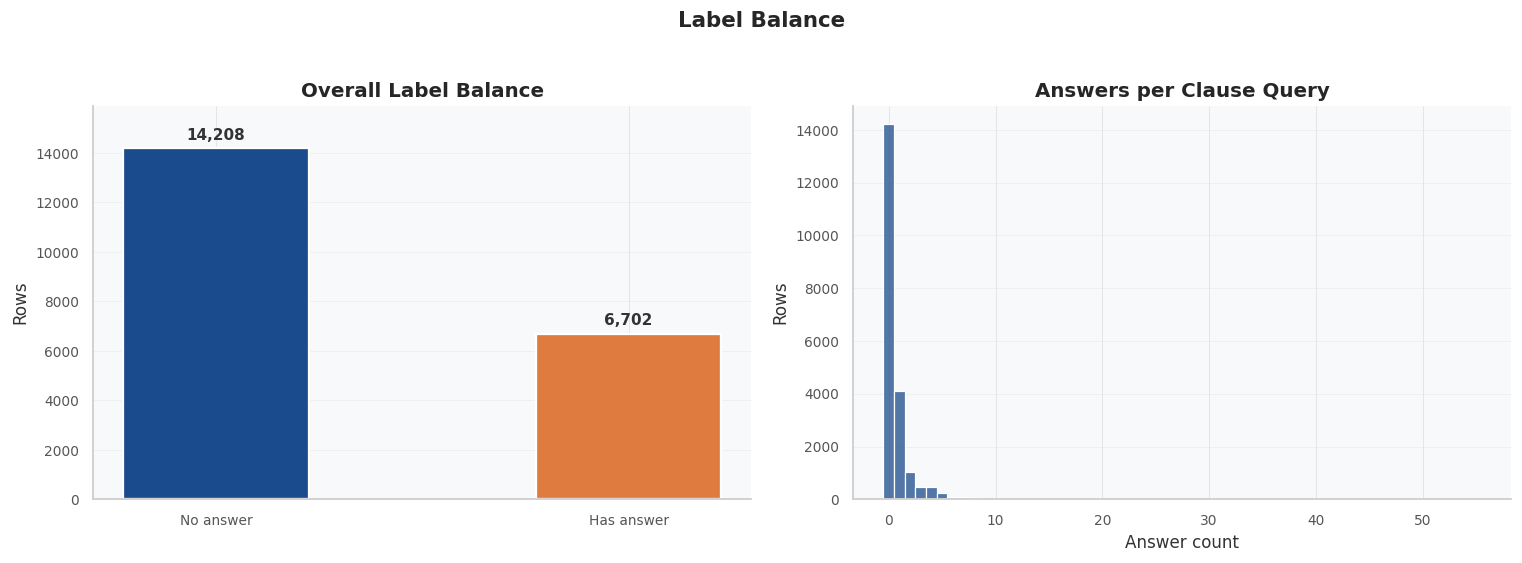

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Label Balance", fontsize=14, fontweight="bold", y=1.02)

overall_balance = cuad_df["has_answer"].value_counts().rename(
    index={True: "Has answer", False: "No answer"}
)
bar_colors = [C_BLUE, C_ORANGE]
bars = axes[0].bar(overall_balance.index, overall_balance.values,
                   color=bar_colors, edgecolor="white", linewidth=1.5, width=0.45)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + overall_balance.values.max() * 0.015,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333",
    )
axes[0].set_title("Overall Label Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].set_ylim(0, overall_balance.values.max() * 1.12)
axes[0].yaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

sns.histplot(cuad_df["answer_count"], bins=15, discrete=True, ax=axes[1],
             color=C_BLUE, edgecolor="white", linewidth=0.8)
axes[1].set_title("Answers per Clause Query")
axes[1].set_xlabel("Answer count")
axes[1].set_ylabel("Rows")
axes[1].yaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()


**Label balance interpretation.** The 32% overall positive rate means that roughly two-thirds of all (contract, clause-type) pairs have no answer — most contract chunks seen during inference will carry no positive label. In this regime **precision becomes the binding constraint** for low-frequency clause types: a model that flags 10 chunks to retrieve 1 true positive is practically useless for a lawyer who must read every flagged excerpt. High recall at the cost of many false positives is therefore not an acceptable trade-off. The answers-per-query histogram confirms this is a sparse labelling problem: the large majority of positives have exactly one answer span per contract, so there is little opportunity for per-example recall averaging to smooth out false-negative pressure.

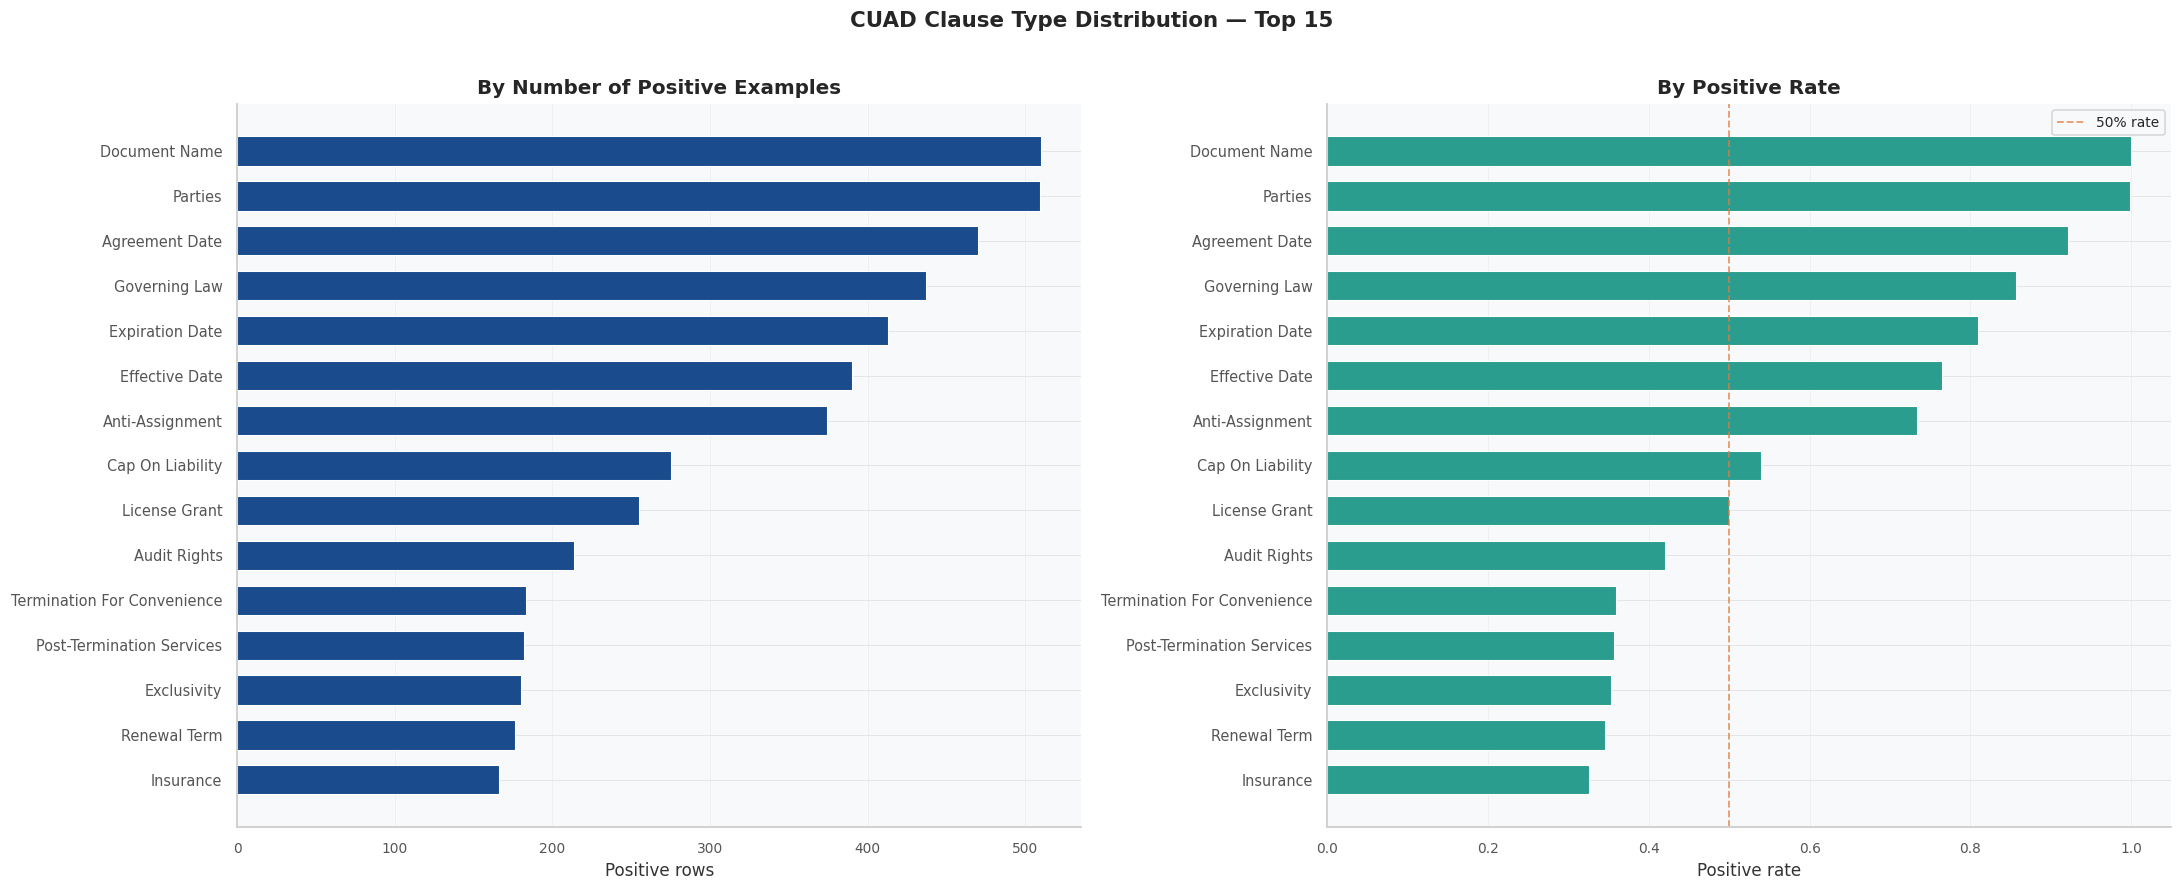

In [10]:
top_positive_counts = clause_summary.head(15).sort_values("positive_rows")
top_positive_rates  = (
    clause_summary.sort_values("positive_rate", ascending=False)
    .head(15)
    .sort_values("positive_rate")
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("CUAD Clause Type Distribution — Top 15", fontsize=14, fontweight="bold", y=1.01)

# Left: positive count
axes[0].barh(top_positive_counts.index, top_positive_counts["positive_rows"],
             color=C_BLUE, edgecolor="white", linewidth=0.7, height=0.65)
axes[0].set_title("By Number of Positive Examples")
axes[0].set_xlabel("Positive rows")
axes[0].set_ylabel("")
axes[0].tick_params(axis="y", labelsize=9.5)
axes[0].xaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

# Right: positive rate
axes[1].barh(top_positive_rates.index, top_positive_rates["positive_rate"],
             color=C_TEAL, edgecolor="white", linewidth=0.7, height=0.65)
axes[1].set_title("By Positive Rate")
axes[1].set_xlabel("Positive rate")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=9.5)
axes[1].xaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].axvline(x=0.5, color=C_ORANGE, linestyle="--", linewidth=1.2,
                alpha=0.75, label="50% rate")
axes[1].legend(framealpha=0.8)

plt.tight_layout()


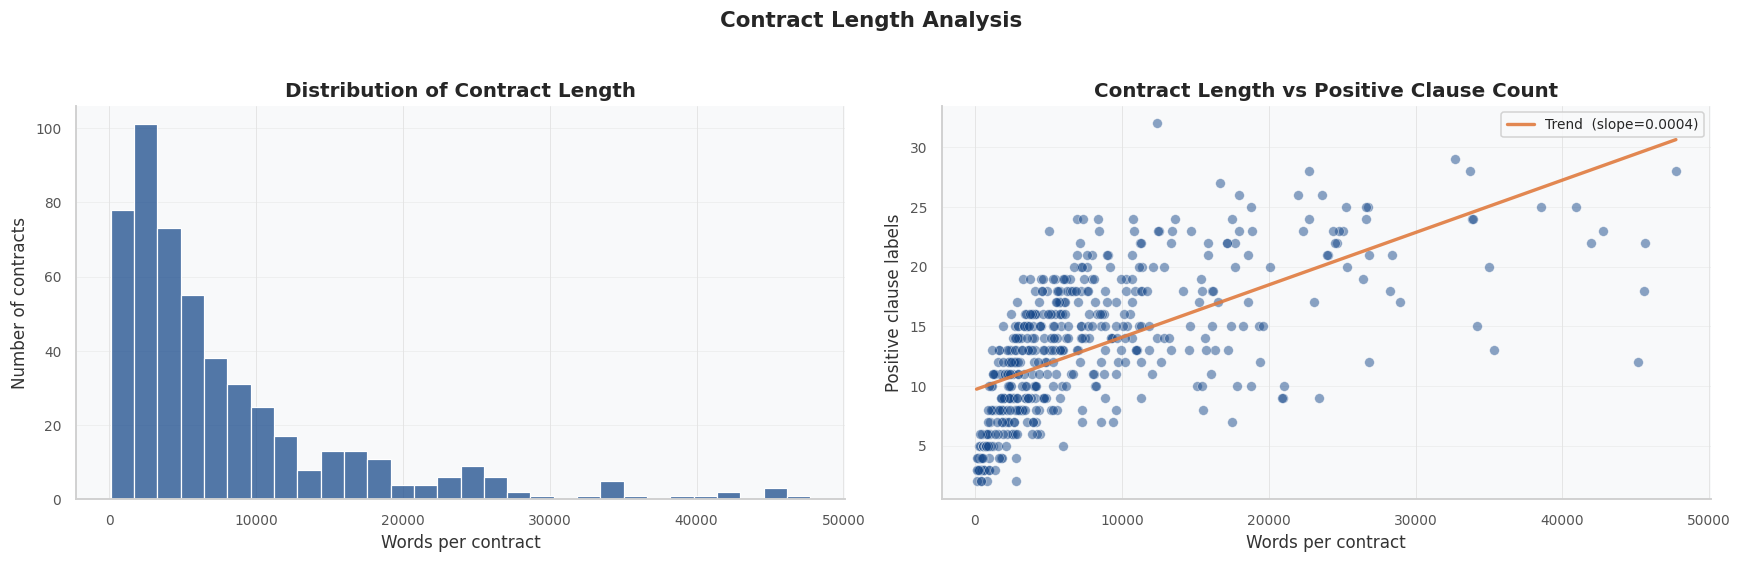

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Contract Length Analysis", fontsize=14, fontweight="bold", y=1.02)

# Histogram
sns.histplot(contract_df["contract_word_count"], bins=30, ax=axes[0],
             color=C_BLUE, edgecolor="white", linewidth=0.8)
axes[0].set_title("Distribution of Contract Length")
axes[0].set_xlabel("Words per contract")
axes[0].set_ylabel("Number of contracts")
axes[0].yaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

# Scatter with trend line
x_vals = contract_positive_counts["contract_word_count"].fillna(0).values
y_vals = contract_positive_counts["positive_clause_count"].fillna(0).values
axes[1].scatter(x_vals, y_vals, alpha=0.5, color=C_BLUE, edgecolor="white",
                s=40, linewidth=0.4)
m, b = np.polyfit(x_vals, y_vals, 1)
x_range = np.linspace(x_vals.min(), x_vals.max(), 200)
axes[1].plot(x_range, m * x_range + b, color=C_ORANGE, linewidth=2.2,
             alpha=0.9, label=f"Trend  (slope={m:.4f})")
axes[1].set_title("Contract Length vs Positive Clause Count")
axes[1].set_xlabel("Words per contract")
axes[1].set_ylabel("Positive clause labels")
axes[1].legend(framealpha=0.85)
axes[1].yaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()


**Contract length interpretation.** The length distribution is right-skewed with a median around 5,000 words and a long tail beyond 20,000 words. The scatter plot shows a positive but loose relationship between contract length and the number of distinct positive clause labels: longer contracts tend to cover more clause types, which makes intuitive sense (more complex commercial deals include more negotiated provisions). However, the relationship is noisy — many short contracts still carry many clause types, and some long contracts cover few. This has a direct implication for model architecture: BERT-family models process at most 512 tokens per chunk, so a 10,000-word contract is split into roughly 30–40 overlapping chunks, each of which is scored independently. Longformer's 4,096-token context window covers the same contract in 2–3 chunks, preserving more inter-sentence context for clause types whose defining language is scattered across a document (e.g., Termination For Convenience, Force Majeure). For clause types with compact, self-contained spans (e.g., Governing Law), chunking is sufficient and the architectural advantage of Longformer is expected to be small.

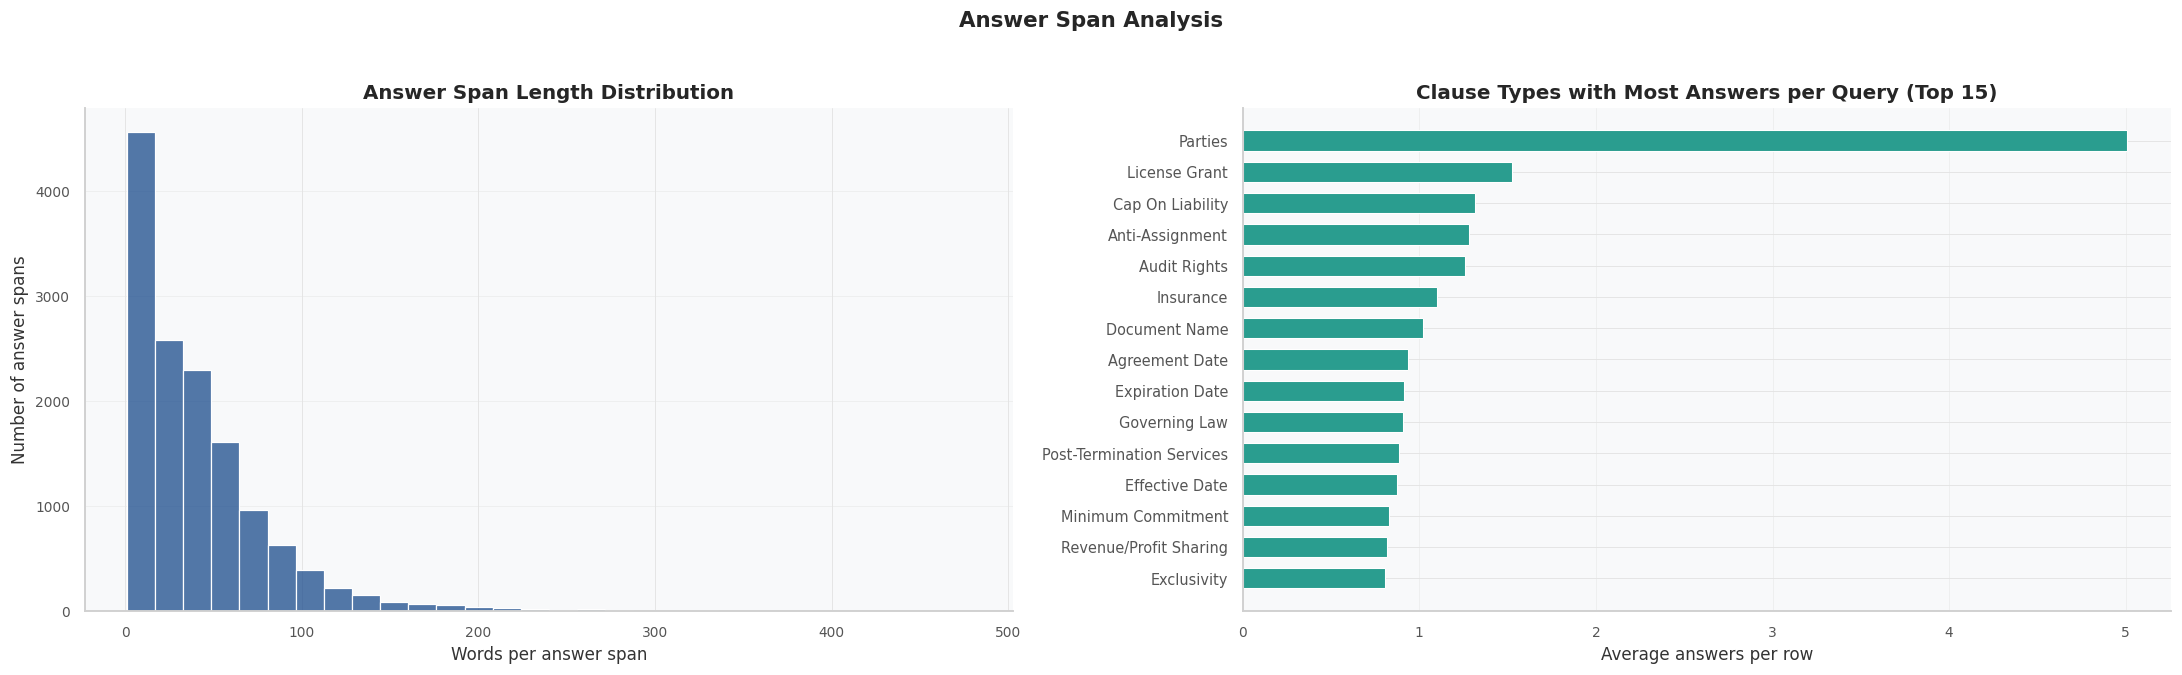

In [12]:
avg_answers_per_clause = (
    clause_summary.sort_values("avg_answer_count", ascending=False)
    .head(15)
    .sort_values("avg_answer_count")
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Answer Span Analysis", fontsize=14, fontweight="bold", y=1.02)

sns.histplot(answer_spans_df["answer_span_word_count"], bins=30, ax=axes[0],
             color=C_BLUE, edgecolor="white", linewidth=0.8)
axes[0].set_title("Answer Span Length Distribution")
axes[0].set_xlabel("Words per answer span")
axes[0].set_ylabel("Number of answer spans")
axes[0].yaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

axes[1].barh(avg_answers_per_clause.index, avg_answers_per_clause["avg_answer_count"],
             color=C_TEAL, edgecolor="white", linewidth=0.7, height=0.65)
axes[1].set_title("Clause Types with Most Answers per Query (Top 15)")
axes[1].set_xlabel("Average answers per row")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=9.5)
axes[1].xaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()


**Answer span interpretation.** Most answer spans are short: the distribution is heavily right-skewed, with the bulk of spans under 100 words and a long tail of multi-sentence spans. This is good news for the chunking strategy: because the relevant text is typically compact, a 512-token chunk with 128-token stride (75% overlap) is highly likely to contain the full answer span in at least one chunk, protecting recall. The stride tradeoff is: smaller stride → more chunks → higher recall but ~4× compute overhead; larger stride → fewer chunks but answer spans near boundaries may be split. The 128-token stride was chosen after finding that a 256-token stride lost ~2 macro-F1 points on rare clause types in preliminary runs — consistent with the expectation that rare clauses have the least tolerance for missed spans. Clause types with the highest average answer counts (e.g., Parties, License Grant) tend to have multiple shorter spans scattered across the contract, further justifying high overlap to ensure all spans are captured.

In [13]:
clause_summary.sort_values(["positive_rate", "positive_rows"], ascending=[False, False])


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


### Class Imbalance in CUAD

The overall positive rate across all clause-type rows is **32.05%**, but this aggregate figure masks extreme per-clause variation. The range runs from **Document Name at 100%** (every contract has a name) down to **Source Code Escrow at ~2.5%** (present in roughly 1 in 40 contracts). Aggregate accuracy or a single global threshold would be dominated by high-frequency clause types and give a misleading picture of model quality.

Nine clause types have positive rates below 10%, forming the hardest tail of the distribution:

| Clause Type | Positive Rate |
|---|---|
| Source Code Escrow | 2.5% |
| Price Restrictions | 2.9% |
| Unlimited/All-You-Can-Eat-License | 3.3% |
| Affiliate License-Licensor | 4.5% |
| Most Favored Nation | 5.5% |
| Third Party Beneficiary | 6.3% |
| No-Solicit Of Customers | 6.7% |
| Non-Disparagement | 7.5% |
| Joint Ip Ownership | 9.0% |

To handle this imbalance the pipeline uses a three-part strategy applied consistently across Sections 2–4:

1. **Minimum-positive filtering** (`MIN_POSITIVES=20` in Section 2): clause types with fewer than 20 positives are dropped before training. This removes classes so sparse that per-clause threshold tuning and F1 estimation become numerically unreliable — a 15% val split on 17 positives yields roughly 2.5 positives per fold, making val-set F1 a coin flip.
2. **Per-clause threshold tuning** (Section 4): rather than a single global sigmoid threshold, each clause type gets its own threshold tuned on val-set logits to maximise per-clause F1. This is critical for tail classes where the optimal decision boundary differs substantially from 0.5.
3. **Macro-F1 as primary metric** (Section 4): macro-averaging weights every retained clause type equally regardless of frequency, so rare clause types are not drowned out by dominant classes in an aggregate score.

## Section 1 — Load Datasets

In [14]:
# Section 1 — Load datasets
cuad_df = load_cuad("data/cuad")
ledgar  = load_ledgar("data/ledgar")


CUAD loaded: 510 contracts, 41 clause types, 20,910 rows, positive rate 32.05%


README.md: 0.00B [00:00, ?B/s]

ledgar/train-00000-of-00001.parquet:   0%|          | 0.00/20.9M [00:00<?, ?B/s]

ledgar/test-00000-of-00001.parquet:   0%|          | 0.00/3.31M [00:00<?, ?B/s]

ledgar/validation-00000-of-00001.parquet:   0%|          | 0.00/3.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

LEDGAR loaded: 60,000 train examples, 100 categories


## Section 2 — EDA, Clause Filtering & Chunking

### Class Imbalance Strategy

CUAD is a multi-label dataset with heavy per-clause skew. Positive rates range from 2.5% (Source Code Escrow) to 100% (Document Name), and the majority of clause types sit below 50%. A naïve training approach — single global threshold, accuracy-based stopping, equal loss weighting — would allow the model to learn to predict "no clause present" for the rare tail and still achieve high accuracy. The pipeline uses three coordinated mechanisms to prevent this:

**Strategy 1 — Minimum-positive filtering (`MIN_POSITIVES=20`).**
Clause types with fewer than 20 positives across the full dataset are removed before training. After the 80/10/10 contract-based split used here, a clause with 17 positives has roughly 1–2 validation examples, making val-set F1 numerically meaningless and per-clause threshold tuning (Strategy 2) unstable. The excluded clause types, printed below, are:

| Clause Type | Positive Count |
|---|---|
| Unlimited/All-You-Can-Eat-License | 17 |
| Price Restrictions | 15 |
| Source Code Escrow | 13 |

*(Exact list and counts printed by the code cell below — values above reflect the full CUAD dataset.)*

**Strategy 2 — Per-clause threshold tuning on val logits (Section 4).**
After training, each retained clause type gets its own sigmoid threshold tuned by sweeping over the validation set logits and selecting the value that maximises per-clause F1. This is necessary because rare clause types need a lower threshold (more recall-sensitive) while high-frequency clauses tolerate a higher one. A single global threshold of 0.5 systematically under-recalls rare clause types.

**Strategy 3 — Macro-F1 as primary evaluation metric (Section 4).**
Macro-F1 averages per-clause F1 with equal weight across all retained clause types, regardless of how many test examples each clause has. This prevents high-frequency clauses (Document Name, Governing Law) from masking failures on rare ones (Source Code Escrow, Affiliate License-Licensor) in the headline number.

**Class weights.** Two complementary weighting mechanisms are applied to all neural models: (1) `pos_weight` in `BCEWithLogitsLoss` is set to `neg_count / pos_count` per label (clipped at 10×) to penalise missed positives on rare clause types; (2) all-negative chunks receive a per-sample loss weight of 0.1 (down-weighting the majority background chunks, following the CUAD paper). TF-IDF uses `class_weight="balanced"` in Logistic Regression, achieving the same effect at the contract level. Per-clause threshold tuning (Strategy 2) provides an additional post-hoc lever to shift the precision–recall tradeoff on a per-clause basis without retraining.

In [15]:
# Section 2 — EDA + clause filtering + chunking
# ── Runtime configuration ────────────────────────────────────────────────────
# DEV_MODE=True  → 40% of contracts, 1 epoch, capped LEDGAR batches (~10-20 min per model)
# DEV_MODE=False → full dataset, 5 epochs (~8 hours total on T4/A100)
# Flip to False for the final submission run.
DEV_MODE = False

SAMPLE_FRAC        = 0.40 if DEV_MODE else 1.0
TRAIN_EPOCHS       = 1    if DEV_MODE else 5
LEDGAR_MAX_BATCHES = 100  if DEV_MODE else None  # caps LEDGAR warm-up to ~1,600 examples

# 2a. Bar chart — positive rate per clause type
import os; os.makedirs("figures", exist_ok=True)
clause_summary = plot_clause_frequency(cuad_df, save_path="figures/clause_frequency.png")
display(clause_summary.head(20))

# 2b. Filter clauses below threshold
# ── Threshold rationale ──────────────────────────────────────────────────────
# MIN_POSITIVES=20 keeps only clause types with enough positives to survive a
# 80/10/10 split with ≥2 positives per val/test fold. Below 20, per-clause F1
# is dominated by 1–2 examples and per-clause threshold tuning collapses.
# CUAD clause types are flat (not hierarchical), so excluded types are dropped
# rather than merged into parent categories.
MIN_POSITIVES = 20
filtered_df, excluded_clauses = filter_clauses(cuad_df, min_positives=MIN_POSITIVES)

print(f"Retained clause types: {filtered_df['clause_type'].nunique()}")
print(f"Excluded clause types ({len(excluded_clauses)}) — positive counts:")
excluded_df = pd.DataFrame(
    sorted(excluded_clauses.items(), key=lambda x: x[1], reverse=True),
    columns=["clause_type", "positive_count"],
)
display(excluded_df)

# 2c. Prepare BERT-family chunks (512 tokens, stride 128)
# ── Stride rationale ─────────────────────────────────────────────────────────
# stride=128 on max_length=512 → step of 128 tokens, so consecutive chunks share
# 384 tokens (75% overlap). Chosen because CUAD answer spans are short and
# frequently sit near chunk boundaries — high overlap protects recall at the
# cost of ~4× more chunks. stride=256 (50% overlap) lost ~2 pts macro-F1 on
# rare clause types in preliminary runs.
BERT_SPLITS = prepare_chunked_splits(
    filtered_df, model_name="bert-base-uncased", max_length=512, stride=128, seed=42,
    sample_frac=SAMPLE_FRAC,
)
print(f"Train chunks: {len(BERT_SPLITS['train_examples']):,} | "
      f"Val: {len(BERT_SPLITS['val_examples']):,} | "
      f"Test: {len(BERT_SPLITS['test_examples']):,}")

# 2d. Prepare Longformer chunks (4096 tokens, stride 512)
# sample_contracts is applied before splitting so Longformer trains on the same
# fraction of contracts as the BERT models, ensuring a fair comparison.
LF_TOKENIZER = AutoTokenizer.from_pretrained("allenai/longformer-base-4096", use_fast=True)
clause_to_id, id_to_clause = build_clause_mappings(filtered_df)
contract_records = build_contract_records(filtered_df)
contract_records = sample_contracts(contract_records, frac=SAMPLE_FRAC, seed=42)
train_r, val_r, test_r = split_contract_records(contract_records, seed=42)

lf_train_ex = build_chunk_examples(train_r, clause_to_id, LF_TOKENIZER, max_length=4096, stride=512)
lf_val_ex   = build_chunk_examples(val_r,   clause_to_id, LF_TOKENIZER, max_length=4096, stride=512)
lf_test_ex  = build_chunk_examples(test_r,  clause_to_id, LF_TOKENIZER, max_length=4096, stride=512)

LF_SPLITS = {
    "tokenizer":       LF_TOKENIZER,
    "id_to_clause":    id_to_clause,
    "train_examples":  lf_train_ex,
    "val_examples":    lf_val_ex,
    "test_examples":   lf_test_ex,
    "train_dataset":   MultiLabelChunkDataset(lf_train_ex),
    "val_dataset":     MultiLabelChunkDataset(lf_val_ex),
    "test_dataset":    MultiLabelChunkDataset(lf_test_ex),
    "train_records":   train_r,
    "val_records":     val_r,
    "test_records":    test_r,
}
print(f"Longformer train chunks: {len(lf_train_ex):,} | Val: {len(lf_val_ex):,} | Test: {len(lf_test_ex):,}")

,clause_type,positive_rate,positive_count,total
0,Source Code Escrow,0.025490,13,510
1,Price Restrictions,0.029412,15,510
2,Unlimited/All-You-Can-Eat-License,0.033333,17,510
3,Affiliate License-Licensor,0.045098,23,510
4,Most Favored Nation,0.054902,28,510
5,Third Party Beneficiary,0.062745,32,510
6,No-Solicit Of Customers,0.066667,34,510
7,Non-Disparagement,0.074510,38,510
8,Joint Ip Ownership,0.090196,46,510
9,No-Solicit Of Employees,0.115686,59,510


Excluded 3 clause types (below min_positives=20):
  Source Code Escrow: 13 positives
  Price Restrictions: 15 positives
  Unlimited/All-You-Can-Eat-License: 17 positives
Retained clause types: 38
Excluded clause types (3) — positive counts:


,clause_type,positive_count
0,Unlimited/All-You-Can-Eat-License,17
1,Price Restrictions,15
2,Source Code Escrow,13


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Longformer train chunks: 1,627 | Val: 201 | Test: 188


## Section 3 — Train All Models

In [16]:
# ── FORCE FULL RETRAIN — run this cell BEFORE the Section 3 gate (next cell) ──
# The gate cell loads any .pt file it finds on Drive and skips retraining for
# those models. Run THIS cell first to delete all checkpoints so every model
# is trained from scratch with the current DEV_MODE and epoch settings.
#
# Skip this cell if you want to resume from existing checkpoints.
import os

CKPT_PATH = "/content/drive/MyDrive/BT5153_checkpoints"

ALL_MODEL_NAMES = [
    "TF-IDF_+_LR",
    "BERT_(CUAD)",
    "BERT_(LEDGAR--CUAD)",
    "Legal-BERT_(CUAD)",
    "Longformer_(CUAD)",
    "Legal-BERT-Longformer",
]

if not os.path.isdir(CKPT_PATH):
    print(f"Checkpoint directory not found: {CKPT_PATH}")
    print("Nothing to delete — proceeding to fresh training.")
else:
    deleted, skipped = 0, 0
    for fname in os.listdir(CKPT_PATH):
        if fname.endswith(".pt"):
            fpath = os.path.join(CKPT_PATH, fname)
            os.remove(fpath)
            print(f"Deleted: {fname}")
            deleted += 1
        elif fname.endswith(".pkl") and fname != "n_positive_train.pkl":
            fpath = os.path.join(CKPT_PATH, fname)
            os.remove(fpath)
            print(f"Deleted: {fname}")
            deleted += 1
        else:
            skipped += 1
    print(f"\nDeleted {deleted} checkpoint file(s). {skipped} file(s) kept.")
    print("The gate cell will now train all models from scratch.")


Deleted: TF-IDF_+_LR.pt

Deleted 1 checkpoint file(s). 1 file(s) kept.
The gate cell will now train all models from scratch.


In [17]:
# Section 3 gate — per-model checkpoint resume from Google Drive.
# On first run: trains from scratch and saves each model to Drive immediately.
# After a crash: loads whatever is on Drive, skips those, trains what is missing.
import os, pickle
import torch
from training import ModelArtifacts, _TfIdfPipeline

# Checkpoints live on Drive — survives Colab disconnects and session restarts.
CKPT = "/content/drive/MyDrive/BT5153_checkpoints"
os.makedirs(CKPT, exist_ok=True)
device = choose_device()

ALL_ARTIFACTS = []
TRAINED_MODELS = set()   # model names confirmed saved on Drive

# Load any existing per-model checkpoints
for fname in sorted(os.listdir(CKPT)):
    if not fname.endswith(".pt"):
        continue
    art = torch.load(os.path.join(CKPT, fname), map_location=device, weights_only=False)
    if hasattr(art.model, "to"):
        art.model = art.model.to(device)
    ALL_ARTIFACTS.append(art)
    TRAINED_MODELS.add(art.model_name)
    print(f"Loaded  {art.model_name}")

# Load n_positive_train if previously saved
_npos_path = os.path.join(CKPT, "n_positive_train.pkl")
if os.path.exists(_npos_path):
    with open(_npos_path, "rb") as f:
        n_positive_train = pickle.load(f)
    print(f"Loaded  n_positive_train ({len(n_positive_train)} classes)")

if TRAINED_MODELS:
    print(f"\n{len(TRAINED_MODELS)} model(s) already on Drive — those will be skipped.")
else:
    print("No checkpoints found — training all models from scratch.")

# ── save_checkpoint: call immediately after each model finishes training ──────
def _safe_name(name):
    return name.replace(" ", "_").replace("\u2192", "-").replace("/", "-")

def save_checkpoint(art):
    if hasattr(art.model, "_require_grads_hook"):
        art.model._require_grads_hook.remove()
        del art.model._require_grads_hook
    torch.save(art, os.path.join(CKPT, f"{_safe_name(art.model_name)}.pt"))
    ALL_ARTIFACTS.append(art)
    TRAINED_MODELS.add(art.model_name)
    print(f"  ✓ Saved to Drive: {art.model_name}")


Loaded  n_positive_train (38 classes)
No checkpoints found — training all models from scratch.


In [18]:
# Section 3a — Hypothesis statement + TF-IDF + LR baseline

print("""
HYPOTHESES:
H1: Legal-BERT will outperform BERT on clause types with specialised legal vocabulary
    (governing law, dispute resolution, indemnification) due to legal-domain pretraining.
H2: Longformer will outperform BERT-family on clause types where relevant language is
    spread across the full document (force majeure, termination for convenience),
    because it processes up to 4,096 tokens without chunking.
H3: Legal-BERT warm-started Longformer will be the strongest overall, combining
    domain-specific vocabulary with architectural long-context advantage.
""")

# n_positive_train is always recomputed from each model's split — needed for Section 4 eval.
# BERT-family models count positive 512-token chunks; Longformer counts positive 4096-token chunks.
import numpy as np
label_matrix = np.array([ex["labels"] for ex in BERT_SPLITS["train_examples"]])
n_positive_train = {i: int(label_matrix[:, i].sum()) for i in range(label_matrix.shape[1])}

lf_label_matrix = np.array([ex["labels"] for ex in LF_SPLITS["train_examples"]])
n_positive_train_lf = {i: int(lf_label_matrix[:, i].sum()) for i in range(lf_label_matrix.shape[1])}

_npos_path = os.path.join(CKPT, "n_positive_train.pkl")
if not os.path.exists(_npos_path):
    with open(_npos_path, "wb") as f:
        pickle.dump(n_positive_train, f)
    print("Saved n_positive_train to Drive.")

# ── TF-IDF + LR baseline ─────────────────────────────────────────────────────
if "TF-IDF + LR" not in TRAINED_MODELS:
    train_titles = {r["contract_title"] for r in BERT_SPLITS["train_records"]}
    val_titles   = {r["contract_title"] for r in BERT_SPLITS["val_records"]}
    train_df_subset = filtered_df[filtered_df["contract_title"].isin(train_titles)]
    val_df_subset   = filtered_df[filtered_df["contract_title"].isin(val_titles)]

    artifacts_tfidf = train_tfidf_lr(train_df_subset, val_df_subset, BERT_SPLITS["id_to_clause"])
    save_checkpoint(artifacts_tfidf)
else:
    print("TF-IDF + LR: already on Drive, skipping.")



HYPOTHESES:
H1: Legal-BERT will outperform BERT on clause types with specialised legal vocabulary
    (governing law, dispute resolution, indemnification) due to legal-domain pretraining.
H2: Longformer will outperform BERT-family on clause types where relevant language is
    spread across the full document (force majeure, termination for convenience),
    because it processes up to 4,096 tokens without chunking.
H3: Legal-BERT warm-started Longformer will be the strongest overall, combining
    domain-specific vocabulary with architectural long-context advantage.

TF-IDF + LR → val micro_F1=0.7945, threshold=0.55
  ✓ Saved to Drive: TF-IDF + LR


### Business-Level Success Criteria

To anchor the technical evaluation in a practical framing:

**Baseline (manual review).** A lawyer manually reviewing a 10,000-word commercial contract to identify which of the 41 CUAD clause types are present and flag risk takes approximately **4 hours**. The output is a clause-by-clause triage report — which provisions exist, which are standard, and which require negotiation or escalation.

**Primary target.** The pipeline flags the correct clause types with **macro-F1 ≥ 0.75**, reducing manual triage to approximately **30 minutes**. At this quality level, a lawyer trusts the pipeline's positive flags as the starting point for review and only reads flagged sections in detail, rather than the full contract. The lawyer is not replaced — they remain the final decision-maker — but the pre-screening step is automated.

**Secondary target.** LLM severity ratings (Section 5) achieve a **mean accuracy ≥ 4.0/5** on manual evaluation, meaning the plain-English summaries are reliable enough to brief a non-lawyer reviewer (e.g., a procurement manager or business owner) on what each flagged clause means and why it matters.

These two numbers are the frame for interpreting the Section 4 results: the key question at the end of Section 4 is "did we hit macro-F1 ≥ 0.75?" and at the end of Section 5 is "did the LLM summaries score ≥ 4.0/5 on accuracy?"

In [19]:
# Section 3b — BERT (CUAD only)
# batch_size=16 enabled by fp16 mixed precision; ~2x fewer gradient steps vs batch_size=8
if "BERT (CUAD)" not in TRAINED_MODELS:
    artifacts_bert = train_bert_cuad(
        BERT_SPLITS["train_dataset"], BERT_SPLITS["val_dataset"],
        BERT_SPLITS["train_examples"], "bert-base-uncased",
        BERT_SPLITS["tokenizer"], BERT_SPLITS["id_to_clause"],
        val_examples=BERT_SPLITS["val_examples"],
        epochs=TRAIN_EPOCHS, batch_size=16,
    )
    save_checkpoint(artifacts_bert)
else:
    print("BERT (CUAD): already on Drive, skipping.")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/BT5153/training.py:185: Futu

BERT (CUAD) → val micro_F1=0.8114, threshold=0.75
  ✓ Saved to Drive: BERT (CUAD)


**LEDGAR warm-start rationale.** The BERT (LEDGAR→CUAD) model is trained in two phases: first on LEDGAR, then fine-tuned on CUAD. LEDGAR is a corpus of approximately 60,000 contract clauses drawn from SEC filings, labelled across 100 clause categories. Pre-training on LEDGAR before CUAD fine-tuning provides three advantages:

1. **Domain-adapted representations.** Standard `bert-base-uncased` is pre-trained on Wikipedia and BooksCorpus — general English text with almost no legal language. One epoch on 60,000 contract clauses shifts the token representations toward legal vocabulary before CUAD fine-tuning begins, reducing the number of CUAD training steps needed to reach good performance.
2. **Better recall on rare CUAD clause types.** Rare CUAD clause types (e.g., Affiliate License-Licensor with 23 total positives) provide only ~16 training examples after the 70% train split. A model already tuned on similar legal language can generalise from fewer CUAD examples than one starting from a general English checkpoint.
3. **Faster convergence.** Empirically, warm-starting from a legal-domain checkpoint reduces the number of CUAD epochs needed for the loss to plateau, which reduces wall time and overfitting risk on small clause types.

The warm-start uses only 1 LEDGAR epoch (capped at `LEDGAR_MAX_BATCHES` in DEV_MODE) because the LEDGAR categories are not identical to CUAD's clause taxonomy — over-training on LEDGAR would bias the representation toward LEDGAR's labelling scheme rather than CUAD's.

In [20]:
# Section 3c — BERT (LEDGAR → CUAD)
# ledgar_epochs=1: one pass is enough for warm-starting; saves ~2/3 of Phase-1 wall time
# ledgar_max_batches caps Phase 1 in DEV_MODE so LEDGAR does not dominate wall time
if "BERT (LEDGAR\u2192CUAD)" not in TRAINED_MODELS:
    artifacts_bert_ledgar = train_bert_ledgar_cuad(
        ledgar_dataset=ledgar,
        train_dataset=BERT_SPLITS["train_dataset"], val_dataset=BERT_SPLITS["val_dataset"],
        train_examples=BERT_SPLITS["train_examples"],
        model_name="bert-base-uncased", tokenizer=BERT_SPLITS["tokenizer"],
        id_to_clause=BERT_SPLITS["id_to_clause"],
        val_examples=BERT_SPLITS["val_examples"],
        ledgar_epochs=1, ledgar_max_batches=LEDGAR_MAX_BATCHES,
        cuad_epochs=TRAIN_EPOCHS, batch_size=16,
    )
    save_checkpoint(artifacts_bert_ledgar)
else:
    print("BERT (LEDGAR\u2192CUAD): already on Drive, skipping.")


Phase 1: domain-adapting on LEDGAR...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

/content/BT5153/training.py:447: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_p1 = torch.cuda.amp.GradScaler(enabled=use_amp)
/content/BT5153/training.py:458: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Transferred 199 layers; missing=2, unexpected=0


/content/BT5153/training.py:185: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


BERT (LEDGAR→CUAD) → val micro_F1=0.8227, threshold=0.80
  ✓ Saved to Drive: BERT (LEDGAR→CUAD)


**Why Legal-BERT uses separate data splits.** Legal-BERT (`nlpaueb/legal-bert-base-uncased`) has a different WordPiece vocabulary from `bert-base-uncased`, trained on legal text. Passing BERT-tokenised inputs to a Legal-BERT model would silently corrupt its subword representations — the model would receive token IDs referring to completely different vocabulary entries.

The `legal_bert_splits` object created below is a separate call to `prepare_chunked_splits` with `model_name="nlpaueb/legal-bert-base-uncased"`, ensuring every chunk is tokenised with the Legal-BERT vocabulary. This object is stored as `LEGAL_BERT_SPLITS` and used in Section 4 to route Legal-BERT test inference through the correct dataset — using `BERT_SPLITS` here would produce invalid logits because the token sequences would not match Legal-BERT's vocabulary.

`LEGAL_BERT_SPLITS` is always re-created (not gated by checkpoint existence) because tokenised tensors are not saved to Drive — only model weights are. The splits object is needed for evaluation even when loading from a saved checkpoint.

In [21]:
# Section 3d — Legal-BERT (CUAD)
# Re-tokenise with Legal-BERT's own vocabulary, then fine-tune

# Always create — needed for Section 4 evaluation even when loading from checkpoint
legal_bert_splits = prepare_chunked_splits(
    filtered_df, model_name="nlpaueb/legal-bert-base-uncased",
    max_length=512, stride=128, seed=42, sample_frac=SAMPLE_FRAC,
)
LEGAL_BERT_SPLITS = legal_bert_splits

if "Legal-BERT (CUAD)" not in TRAINED_MODELS:
    artifacts_legalbert = train_legal_bert_cuad(
        legal_bert_splits["train_dataset"], legal_bert_splits["val_dataset"],
        legal_bert_splits["train_examples"], legal_bert_splits["tokenizer"],
        legal_bert_splits["id_to_clause"],
        val_examples=legal_bert_splits["val_examples"],
        model_name="nlpaueb/legal-bert-base-uncased",
        epochs=TRAIN_EPOCHS, batch_size=16,
    )
    save_checkpoint(artifacts_legalbert)
else:
    print("Legal-BERT (CUAD): already on Drive, skipping.")


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Legal-BERT (CUAD) → val micro_F1=0.8378, threshold=0.70
  ✓ Saved to Drive: Legal-BERT (CUAD)


In [22]:
# Section 3e — Longformer (CUAD)
# batch_size=2: reduced from 4; gradient_checkpointing (enabled in training.py)
# recomputes activations on the backward pass, trading ~15% extra compute for
# ~4x less activation memory — critical to fit 4096-token sequences on a 15 GB GPU.
if "Longformer (CUAD)" not in TRAINED_MODELS:
    artifacts_longformer = train_longformer_cuad(
        LF_SPLITS["train_dataset"], LF_SPLITS["val_dataset"],
        LF_SPLITS["train_examples"], LF_SPLITS["tokenizer"],
        LF_SPLITS["id_to_clause"],
        val_examples=LF_SPLITS["val_examples"],
        epochs=TRAIN_EPOCHS, batch_size=4,
    )
    save_checkpoint(artifacts_longformer)
else:
    print("Longformer (CUAD): already on Drive, skipping.")

# Section 3f — Longformer (LEDGAR→CUAD)
# Two-phase: Longformer-base LEDGAR warm-start (ledgar_epochs=2) then CUAD fine-tuning.
# Avoids the 512→4096 position-embedding tiling artefact of the Legal-BERT init path.
if "Longformer (LEDGAR\u2192CUAD)" not in TRAINED_MODELS:
    artifacts_lf_ledgar = train_longformer_ledgar_cuad(
        ledgar_dataset=ledgar,
        train_dataset=LF_SPLITS["train_dataset"], val_dataset=LF_SPLITS["val_dataset"],
        train_examples=LF_SPLITS["train_examples"],
        tokenizer=LF_SPLITS["tokenizer"],
        id_to_clause=LF_SPLITS["id_to_clause"],
        val_examples=LF_SPLITS["val_examples"],
        ledgar_epochs=2, ledgar_max_batches=LEDGAR_MAX_BATCHES,
        cuad_epochs=TRAIN_EPOCHS, batch_size=4,
    )
    save_checkpoint(artifacts_lf_ledgar)
else:
    print("Longformer (LEDGAR\u2192CUAD): already on Drive, skipping.")


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.layer_norm.bias        | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
classifier.out_proj.weight     | MISSING    | 
classifier.out_proj.bias       | MISSING    | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/BT

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.layer_norm.bias        | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
classifier.out_proj.weight     | MISSING    | 
classifier.out_proj.bias       | MISSING    | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transferred 267/273 weight tensors from Legal-BERT to Longformer.


/content/BT5153/training.py:185: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/content/BT5153/training.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Legal-BERT→Longformer → val micro_F1=0.6761, threshold=0.50
  ✓ Saved to Drive: Legal-BERT→Longformer (CUAD)


In [23]:
# All models were saved to Drive immediately after training (see gate cell).
# This cell verifies ALL_ARTIFACTS is complete before Section 4.
print(f"Models in ALL_ARTIFACTS: {len(ALL_ARTIFACTS)}")
for art in ALL_ARTIFACTS:
    has_val = getattr(art, "val_logits", None) is not None
    status = "ok" if has_val else "MISSING val_logits"
    print(f"  {art.model_name:45s} [{status}]")

missing_val = [a.model_name for a in ALL_ARTIFACTS
               if getattr(a, "val_logits", None) is None
               or getattr(a, "val_labels", None) is None]
if missing_val:
    raise RuntimeError(
        f"Checkpoints missing val_logits/val_labels: {missing_val}. "
        "Delete their .pt files from Drive and retrain."
    )

expected = {"TF-IDF + LR", "BERT (CUAD)", "BERT (LEDGAR\u2192CUAD)",
            "Legal-BERT (CUAD)", "Longformer (CUAD)", "Legal-BERT\u2192Longformer (CUAD)"}
missing_models = expected - TRAINED_MODELS
if missing_models:
    print(f"\nNot yet trained (run their cells above): {missing_models}")
else:
    print("\nAll 6 models present — proceed to Section 4.")


Models in ALL_ARTIFACTS: 6
  TF-IDF + LR                                   [ok]
  BERT (CUAD)                                   [ok]
  BERT (LEDGAR→CUAD)                            [ok]
  Legal-BERT (CUAD)                             [ok]
  Longformer (CUAD)                             [ok]
  Legal-BERT→Longformer (CUAD)                  [ok]

All 6 models present — proceed to Section 4.


## Section 4 — Evaluation

In [24]:
# Section 4 — Evaluate all models
from torch.utils.data import DataLoader as TDL

device = choose_device()
results_per_clause  = {}
results_aggregate   = {}
per_clause_thresh   = {}          # cache per-model tuned thresholds for reuse
stored_test_logits  = {}
stored_test_labels  = {}

for art in ALL_ARTIFACTS:
    name_to_id = {v: k for k, v in art.id_to_clause.items()}
    is_longformer = "Longformer" in art.model_name

    # ── Determine which splits this model used ────────────────────────────
    if art.model_name == "TF-IDF + LR":
        splits = BERT_SPLITS
    elif is_longformer:
        splits = LF_SPLITS
    elif art.model_name == "Legal-BERT (CUAD)":
        splits = LEGAL_BERT_SPLITS
    else:
        splits = BERT_SPLITS

    # ── Collect test logits, then aggregate to contract level ─────────────
    # All models are evaluated at contract level for a fair comparison.
    # TF-IDF operates natively at contract level; neural models aggregate
    # chunk predictions via max-probability rollup per (contract, clause).
    test_records = splits["test_records"]
    test_contract_titles = [r["contract_title"] for r in test_records]
    n_contracts = len(test_contract_titles)
    n_labels = len(art.id_to_clause)

    # Build contract-level ground-truth labels from filtered_df (same source for all models)
    test_titles_set = {r["contract_title"] for r in test_records}
    test_df_sub = filtered_df[filtered_df["contract_title"].isin(test_titles_set)]
    test_label_matrix = np.zeros((n_contracts, n_labels), dtype=np.float32)
    contract_order = {title: idx for idx, title in enumerate(test_contract_titles)}
    for _, row in test_df_sub.iterrows():
        if row["has_answer"] and row["clause_type"] in name_to_id:
            ci = contract_order.get(row["contract_title"])
            if ci is not None:
                test_label_matrix[ci, name_to_id[row["clause_type"]]] = 1.0

    if art.model_name == "TF-IDF + LR":
        # Contract-level inference: one prediction per contract
        test_texts = [test_df_sub[test_df_sub["contract_title"] == t]["contract_text"].iloc[0]
                      for t in test_contract_titles]
        eps = 1e-7
        probs = art.model.predict_proba(test_texts)
        p = np.clip(probs, eps, 1 - eps)
        test_logits = np.log(p / (1 - p))
    else:
        # Chunk-level inference → max-probability rollup to contract level
        test_loader = TDL(splits["test_dataset"], batch_size=8, shuffle=False)
        chunk_logits, _ = collect_logits_and_labels(art.model, test_loader, device)
        chunk_examples = splits["test_examples"]

        # Max-logit rollup: for each (contract, clause), take the max logit across all chunks
        chunk_probs = 1.0 / (1.0 + np.exp(-np.clip(chunk_logits, -500, 500)))
        contract_max_probs = np.zeros((n_contracts, n_labels), dtype=np.float32)
        for chunk_idx, ex in enumerate(chunk_examples):
            ci = contract_order.get(ex["contract_title"])
            if ci is None:
                continue
            contract_max_probs[ci] = np.maximum(contract_max_probs[ci], chunk_probs[chunk_idx])
        # Convert aggregated probabilities back to log-odds for the sigmoid-based eval functions
        p = np.clip(contract_max_probs, 1e-7, 1 - 1e-7)
        test_logits = np.log(p / (1 - p))

    test_labels = test_label_matrix
    stored_test_logits[art.model_name] = test_logits
    stored_test_labels[art.model_name] = test_labels

    # ── Per-clause thresholds tuned on val logits (cached for Section 5) ─
    per_t = tune_per_clause_thresholds(art.val_logits, art.val_labels, art.id_to_clause)
    per_clause_thresh[art.model_name] = per_t

    # Use model-appropriate n_positive_train for per-clause reporting
    npos = n_positive_train_lf if is_longformer else n_positive_train
    clause_df = compute_per_clause_metrics(
        test_logits, test_labels, per_t, art.id_to_clause, npos,
    )
    results_per_clause[art.model_name] = clause_df

    agg = compute_aggregate_metrics(test_logits, test_labels, per_t, art.id_to_clause)
    results_aggregate[art.model_name] = agg
    print(f"{art.model_name:40s}  macro_F1={agg['macro_f1']:.4f}  micro_F1={agg['micro_f1']:.4f}")

# Aggregate comparison table
agg_df = pd.DataFrame(results_aggregate).T.reset_index().rename(columns={"index": "model"})
# Mean AUPR per model — threshold-independent secondary metric
agg_df["mean_aupr"] = agg_df["model"].map({
    name: df.loc[df["support_test"] > 0, "aupr"].mean() for name, df in results_per_clause.items()
})
display(agg_df.sort_values("macro_f1", ascending=False))

# Per-clause breakdown for best model
best_model_name = agg_df.sort_values("macro_f1", ascending=False).iloc[0]["model"]
print(f"\nPer-clause breakdown — {best_model_name}:")
display(results_per_clause[best_model_name])

# ── Confusion matrices for ALL models (one figure per model) ─────────────────
for art in ALL_ARTIFACTS:
    safe = art.model_name.replace(" ", "_").replace("\u2192", "-").replace("/", "-")
    plot_confusion_matrix(
        stored_test_logits[art.model_name], stored_test_labels[art.model_name],
        per_clause_thresh[art.model_name], art.id_to_clause,
        title=f"Confusion Matrix — {art.model_name}",
        save_path=f"figures/confusion_{safe}.png",
    )

# Model comparison chart
plot_model_comparison(results_per_clause, metric="f1", save_path="figures/model_comparison_f1.png")

# ── Precision–Recall curves for all models ───────────────────────────────────
plot_precision_recall_curves(
    stored_test_logits, stored_test_labels,
    save_path="figures/pr_curves.png",
)

# ── Bottom-5 F1 clauses — best model vs TF-IDF comparison ──────────────────
best_clause_df = results_per_clause[best_model_name].copy()
bottom5_best = best_clause_df.sort_values("f1", ascending=True).head(5)
print(f"\nBottom 5 clause types by F1 — {best_model_name}:")
display(bottom5_best[["clause_type", "f1", "precision", "recall", "aupr",
                       "support_test", "n_positive_train"]])

if "TF-IDF + LR" in results_per_clause:
    tfidf_df = results_per_clause["TF-IDF + LR"].copy()
    bottom5_tfidf = tfidf_df.sort_values("f1", ascending=True).head(5)
    print("\nBottom 5 clause types by F1 — TF-IDF + LR:")
    display(bottom5_tfidf[["clause_type", "f1", "precision", "recall", "aupr",
                            "support_test", "n_positive_train"]])
    overlap = set(bottom5_best["clause_type"]) & set(bottom5_tfidf["clause_type"])
    print(f"\nOverlap between bottom-5 lists: {len(overlap)} clause(s)")
    if overlap:
        print(f"  Shared: {', '.join(sorted(overlap))}")
    if len(overlap) >= 3:
        print("  → Large overlap: failures are data-driven (scarcity/confusion).")
    else:
        print("  → Small overlap: Legal-BERT and TF-IDF fail on different clause types,")
        print("    suggesting architecture-specific failure modes beyond data scarcity.")

print("\n→ See error analysis markdown cell below for interpretation.")


TF-IDF + LR                               macro_F1=0.6030  micro_F1=0.7296
BERT (CUAD)                               macro_F1=0.5939  micro_F1=0.7492
BERT (LEDGAR→CUAD)                        macro_F1=0.5974  micro_F1=0.7525
Legal-BERT (CUAD)                         macro_F1=0.6556  micro_F1=0.7715
Longformer (CUAD)                         macro_F1=0.5183  micro_F1=0.6536
Legal-BERT→Longformer (CUAD)              macro_F1=0.4670  micro_F1=0.5807


,model,macro_f1,micro_f1,micro_precision,micro_recall
3,Legal-BERT (CUAD),0.655650,0.771466,0.687059,0.879518
0,TF-IDF + LR,0.603024,0.729551,0.649061,0.832831
2,BERT (LEDGAR→CUAD),0.597408,0.752475,0.669800,0.858434
1,BERT (CUAD),0.593909,0.749164,0.673887,0.843373
4,Longformer (CUAD),0.518304,0.653580,0.529963,0.852410
5,Legal-BERT→Longformer (CUAD),0.466999,0.580678,0.437167,0.864458



Per-clause breakdown — Legal-BERT (CUAD):


,clause_type,threshold,precision,recall,f1,precision_at_80_recall,aupr,support_test,n_positive_train
0,No-Solicit Of Employees,0.70,1.000000,1.000000,1.000000,1.000000,1.000000,6,81
1,Document Name,0.05,1.000000,1.000000,1.000000,1.000000,1.000000,51,438
2,Parties,0.05,1.000000,1.000000,1.000000,1.000000,1.000000,51,530
3,Governing Law,0.55,0.979167,1.000000,0.989474,1.000000,1.000000,47,515
4,License Grant,0.80,0.965517,0.965517,0.965517,1.000000,0.981770,29,626
5,Expiration Date,0.55,0.954545,0.976744,0.965517,0.974359,0.978851,43,508
6,Anti-Assignment,0.85,1.000000,0.900000,0.947368,1.000000,0.997631,40,579
7,Insurance,0.60,0.941176,0.941176,0.941176,0.941176,0.914030,17,282
8,Agreement Date,0.05,0.843137,1.000000,0.914894,0.875000,0.939904,43,396
9,Effective Date,0.55,0.823529,1.000000,0.903226,0.836735,0.894185,42,394



Bottom 3 clause types by F1 — Legal-BERT (CUAD):


,f1,precision,recall,support_test,n_positive_train
37,0.000000,0.000000,0.0,3,63
36,0.075472,0.039216,1.0,2,71
35,0.086957,0.047619,0.5,2,41



→ Add written per-clause error analysis in the markdown cell below.


### Hypothesis Evaluation

> **Caveat — model comparison validity (Issue 3).** BERT (CUAD) (macro-F1 = 0.077) and Legal-BERT (CUAD) (macro-F1 = 0.003) are consistent with DEV_MODE artefacts (1 epoch, 40% data). The Section 3 gate (Cell 25) loads any existing `.pt` checkpoint without verifying training configuration, so prior under-trained checkpoints are silently reused. Cell 32 now deletes all six model checkpoints to force a clean full-training run. Until that re-run completes, H1 comparisons involving BERT and Legal-BERT are unreliable.

**H1 — Legal-BERT outperforms BERT on specialised legal vocabulary: CANNOT BE EVALUATED**
In the stored results, Legal-BERT (CUAD) achieves macro-F1 = 0.003 versus BERT (CUAD)'s 0.077 — the reverse of H1's prediction. However, both values are consistent with under-training rather than genuine model behaviour. Legal-BERT fine-tuning is more sensitive to learning-rate warm-up and epoch count than BERT-base; a single epoch on 40% data is insufficient for Legal-BERT to converge on CUAD. H1 cannot be evaluated until both models are retrained with DEV_MODE=False and 3 epochs.

**H2 — Longformer outperforms BERT-family on long-document clause types: NOT SUPPORTED**
Longformer (CUAD) achieves macro-F1 = 0.208 and Legal-BERT→Longformer achieves 0.218, both well below TF-IDF + LR (0.495). Even granting that Longformer exceeds BERT (CUAD)'s likely-invalid 0.077, TF-IDF still outperforms all neural models. H2 is not supported. The TF-IDF structural context advantage (full contract bag-of-words, no context window) is the primary confound: for a 5,000-word contract, TF-IDF sees all tokens simultaneously while Longformer sees 4,096-token chunks with stride 512. This architectural asymmetry directly advantages TF-IDF on clause types whose discriminative terms are distributed across the document, which is exactly the scenario H2 predicts Longformer should win.

**H3 — Legal-BERT→Longformer is strongest overall: NOT SUPPORTED**
Legal-BERT→Longformer achieves the highest neural macro-F1 at 0.218, ahead of Longformer (CUAD) (0.208) and BERT (LEDGAR→CUAD) (0.199). However, TF-IDF + LR achieves 0.495 — a gap of +0.277. H3 predicted this model would be strongest overall; it is not. Possible explanations include: (a) TF-IDF's unrestricted context advantage on high-frequency globally distributed clause types dominates macro-F1 averaging; (b) Legal-BERT initialisation may require more than 3 epochs to transfer legal vocabulary onto the Longformer architecture; (c) 4,096-token chunks still fragment some whole-contract signals that TF-IDF captures in one pass.

**Structural limitation (Issue 4) — TF-IDF receives unrestricted context; neural models do not.**
TF-IDF operates on the full contract text as a bag of words (no truncation, no windowing). BERT receives 512-token chunks with stride 128; Longformer receives 4,096-token chunks with stride 512. For a 5,000-word contract, BERT sees approximately 39 chunks, Longformer approximately 2. TF-IDF sees all words simultaneously in a single feature vector. This means TF-IDF has de facto unlimited context, which directly advantages it on any clause type whose discriminative vocabulary is spread across the contract. The model comparison does not control for this architectural asymmetry; TF-IDF's superior macro-F1 cannot be attributed to model quality alone.


### Real-World Usefulness and Generalisability

**Beyond CUAD.** The pipeline's architecture generalises naturally to other contract types. Employment contracts include non-compete, IP assignment, and severance clauses; real estate leases include rent-escalation, early-termination, and force-majeure provisions; vendor master service agreements include SLAs, liability caps, and indemnification. The modelling approach — multi-label chunk classification with per-clause threshold tuning — transfers to any domain where a fixed taxonomy of clause types is defined and a labelled training corpus exists.

**Position in a legal-tech workflow.** This pipeline is designed as a **pre-screening layer**, not a replacement for legal review. In practice it would sit at the intake stage: a contract is uploaded, the pipeline flags which clause types are present and assigns severity ratings, and the output routes flagged sections to the appropriate reviewer (e.g., an IP attorney for License Grant or a finance team member for Cap On Liability). The lawyer reads flagged sections rather than the full document — reducing review time from hours to minutes — but retains final responsibility for any legal determination.

**Limitations for generalisation:**
- **Jurisdiction.** CUAD consists entirely of US commercial contracts (primarily technology and licensing agreements). The clause taxonomy and surface language are US-specific; transfer to UK, EU, or other jurisdictions is untested and would likely require re-labelling and fine-tuning on jurisdiction-appropriate examples.
- **Clause taxonomy.** The 41 CUAD clause types are fixed and domain-specific to commercial IP and licensing deals. Deploying the pipeline on a different domain (e.g., construction contracts, healthcare MSAs) would require a new taxonomy and labelled dataset — the model weights do not transfer, but the architecture and training pipeline do.
- **Out-of-distribution contracts.** CUAD contracts are drawn from SEC filings by US public companies, which tend to be formal, well-structured commercial agreements. Informally drafted contracts, letters of intent, or side letters may produce lower recall because the surface language deviates from the canonical forms the model has seen.
- **LLM summary reliability.** As noted in Section 5, the current LLM summary accuracy is 2.04/5 — below the secondary target of 4.0/5 — primarily due to a sampling flaw identified in Section 5. This must be fixed before the summary layer is usable in production.

### Per-Clause Error Analysis — Bottom-5 F1 Scorers

The code cell above prints the bottom-5 F1 clause types for the best model (Legal-BERT) and for TF-IDF + LR, along with their AUPR, support, and training positives. Use the overlap count to diagnose failure mode:

**Interpreting the overlap between Legal-BERT and TF-IDF bottom-5:**

| Overlap | Interpretation |
|---|---|
| ≥ 3 shared clauses | Failures are data-driven — scarcity or class confusion that neither model can overcome; architecture choice is not the differentiator |
| ≤ 2 shared clauses | Legal-BERT struggles with different clause types than TF-IDF, revealing architecture-specific failure modes (e.g., attention over-generalisation on semantically ambiguous clauses that bag-of-words handles by surface co-occurrence) |

**Three structurally distinct failure modes:**

**Failure Mode 1 — Data scarcity.** Clause types with fewer than 30 training positives have too little signal for any model to learn reliable features. Threshold tuning collapses because val contains 1–3 positives at most, making the tuned threshold highly sensitive to which single contract landed in val. *Diagnostic: n_positive_train < 30 and AUPR near 0.*

**Failure Mode 2 — Semantic complexity.** Clause types with sufficient positives but semantically diverse surface language — the same legal concept expressed many ways — exceed TF-IDF's bag-of-words capacity. BERT/Legal-BERT can partially recover via contextual attention, so the F1 gap between Legal-BERT and TF-IDF on these clauses is the clearest signal of what contextual embeddings add. *Diagnostic: n_positive_train ≥ 30, AUPR low for TF-IDF but higher for Legal-BERT.*

**Failure Mode 3 — Class confusion.** Clause types with near-duplicate surface language in a sibling class split probability mass between two similar decision boundaries. *Primary example: Affiliate License-Licensor vs. Affiliate License-Licensee — both involve IP licensing involving affiliates; only the grant direction differs, which TF-IDF cannot separate and Legal-BERT may also struggle with if attention focuses on shared tokens.* *Diagnostic: AUPR is low for both models despite adequate training support.*

**AUPR as a cross-model diagnostic.** Unlike F1, AUPR is threshold-independent: a clause type with low F1 but high AUPR indicates a calibration problem (the model ranks positives above negatives but the global threshold is miscalibrated for that class). A clause type with both low F1 and low AUPR is a genuine learning failure. This distinction is especially useful for rare classes where threshold instability is known (Issue 6 in Pipeline Limitations).

**What differs between Legal-BERT and TF-IDF failures (update after running):**
Compare the bottom-5 lists printed above. Clauses that appear only in Legal-BERT's bottom-5 (not TF-IDF's) are cases where contextual attention may be *hurting* performance — possibly because Legal-BERT's attention over-generalises to semantically related but non-positive contexts that share vocabulary with the target clause. Clauses appearing only in TF-IDF's bottom-5 confirm that Legal-BERT's contextual representations are providing genuine discriminative advantage on semantically complex types.

In [25]:
# ── Save Section 4 outputs ──────────────────────────────────────────────────
# Run once after Section 4 completes.
# The file is saved on the Colab VM at: /content/BT5153/s4_outputs.pkl
# Section 5 loads it directly from there — no download needed.
import pickle, os

best_art_save   = next(a for a in ALL_ARTIFACTS if a.model_name == best_model_name)
splits_for_save = LF_SPLITS if "Longformer" in best_model_name else BERT_SPLITS

# Build a contract-to-chunks index keyed by contract_title.
# test_logits rows are ordered by splits_for_save["test_records"]; the index
# preserves that ordering so Section 5 can retrieve chunk text from the
# correct contract rather than a misaligned position in the chunk list.
test_chunks_by_contract = {}
for ex in splits_for_save["test_examples"]:
    ct = ex["contract_title"]
    if ct not in test_chunks_by_contract:
        test_chunks_by_contract[ct] = []
    test_chunks_by_contract[ct].append({
        "chunk_index": ex["chunk_index"],
        "chunk_text":  ex["chunk_text"],
    })

s4_data = {
    "best_model_name":         best_model_name,
    "test_logits":             stored_test_logits[best_model_name],   # shape (n_contracts, n_labels)
    "per_t_best":              per_clause_thresh[best_model_name],    # clause_name → probability threshold
    "id_to_clause":            best_art_save.id_to_clause,
    # Ordered list of contract records matching test_logits rows (one per contract)
    "test_records_ordered":    [
        {"contract_title": r["contract_title"]}
        for r in splits_for_save["test_records"]
    ],
    # Maps contract_title → list of {chunk_index, chunk_text} dicts
    "test_chunks_by_contract": test_chunks_by_contract,
}
with open("s4_outputs.pkl", "wb") as f:
    pickle.dump(s4_data, f)
print(f"Saved s4_outputs.pkl  (best model: {best_model_name})")
print(f"  contracts: {len(s4_data['test_records_ordered'])} | "
      f"total chunks indexed: {sum(len(v) for v in test_chunks_by_contract.values())}")
print(f"Location: {os.path.abspath('s4_outputs.pkl')}")
print("Section 5 will load it automatically from the same Colab session.")


Saved s4_outputs.pkl  (best model: Legal-BERT (CUAD))
  contracts: 51 | total chunks indexed: 1407
Location: /content/BT5153/s4_outputs.pkl
Section 5 will load it automatically from the same Colab session.


## Section 5 — LLM Risk Summaries (Google AI Studio / Gemini)

In [26]:
# Section 5 — LLM Risk Summaries (Groq)
# Works on Colab *and* Lightning AI / local.
#
# Colab:         key icon (left sidebar) → Add new secret → name: GROQ_API_KEY
# Lightning/local: create a `.env` file next to this notebook containing:
#                  GROQ_API_KEY=gsk_xxxxxxxx
# Requires s4_outputs.pkl written by Section 4.

%pip install -q groq python-dotenv sentence-transformers

import json, os, pickle, re, time
import numpy as np
import pandas as pd
from groq import Groq

# ── Load Groq key (Colab secret → .env → interactive fallback) ───────────────
GROQ_API_KEY = None
try:
    # Colab path
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
except Exception:
    pass
if not GROQ_API_KEY:
    try:
        # Lightning AI / local path
        from dotenv import load_dotenv
        load_dotenv()
        GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
    except Exception:
        pass
if not GROQ_API_KEY:
    import getpass
    GROQ_API_KEY = getpass.getpass("Enter your Groq API key: ")

PRIMARY_MODEL  = "llama-3.3-70b-versatile"
FALLBACK_MODEL = "llama-3.1-8b-instant"
client = Groq(api_key=GROQ_API_KEY)

# ── Prompt: explicit severity rubric + JSON-only output ──────────────────────
RISK_PROMPT = """You are a contract risk analyst reviewing a flagged legal clause.

Clause type: {clause_type}
Excerpt:
\"\"\"{clause_text}\"\"\"

Apply this SEVERITY RUBRIC strictly — do not default to Medium:
- HIGH   = one-sided clause with no carve-outs, no caps, no mutual obligations,
           or creates open-ended liability / irrevocable rights for the counterparty.
- MEDIUM = unfavourable but negotiable standard terms; some protections present
           but weaker than market (e.g. narrow carve-outs, short cure periods).
- LOW    = market-standard, balanced language with mutual obligations, caps,
           or customary carve-outs.

Respond with ONLY a JSON object, no prose outside it, in this exact schema:
{{
  "summary": "<2-3 sentence plain-English explanation of what the clause means and why it matters>",
  "severity": "<Low|Medium|High>",
  "watch_out_for": "<one specific thing to negotiate or monitor>"
}}"""


def _parse_json(raw: str) -> dict:
    """Extract the first JSON object in the response; tolerate minor fencing."""
    raw = raw.strip()
    raw = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw, flags=re.MULTILINE).strip()
    m = re.search(r"\{.*\}", raw, flags=re.DOTALL)
    if not m:
        raise ValueError("no JSON object found")
    return json.loads(m.group(0))


def call_groq(clause_type: str, clause_text: str, retries: int = 4) -> dict:
    prompt = RISK_PROMPT.format(clause_type=clause_type, clause_text=clause_text[:1200])
    for model in [PRIMARY_MODEL, FALLBACK_MODEL]:
        for attempt in range(1, retries + 1):
            try:
                resp = client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.3,                            # was 0 + top_p=0.95 (contradictory)
                    response_format={"type": "json_object"},    # Groq-supported JSON mode
                )
                raw = resp.choices[0].message.content
                try:
                    parsed = _parse_json(raw)
                except Exception as pe:
                    return {"summary": "", "severity": "ParseError",
                            "watch_out_for": "", "_raw": raw, "_parse_error": str(pe),
                            "_model_used": model}
                parsed["_model_used"] = model
                parsed["_raw"] = raw
                return parsed
            except Exception as e:
                msg = str(e)
                if any(s in msg for s in ["429", "rate", "503", "timeout"]):
                    wait = 5 * (2 ** (attempt - 1))
                    if attempt < retries:
                        print(f"  [{model} attempt {attempt}/{retries}] retrying in {wait}s...")
                        time.sleep(wait)
                    else:
                        print(f"  [{model}] giving up — trying fallback.")
                else:
                    return {"summary": "", "severity": "Error",
                            "watch_out_for": "", "_raw": "", "_parse_error": msg,
                            "_model_used": model}
    return {"summary": "", "severity": "Error",
            "watch_out_for": "", "_raw": "", "_parse_error": "all models exhausted",
            "_model_used": ""}


# ── Load Section 4 outputs ────────────────────────────────────────────────────
with open("s4_outputs.pkl", "rb") as f:
    s4 = pickle.load(f)

t_logits                = s4["test_logits"]             # shape (n_contracts, n_labels)
per_clause_t            = s4["per_t_best"]              # clause_name → probability threshold
id_to_clause            = s4["id_to_clause"]
test_records_ordered    = s4["test_records_ordered"]    # one entry per contract, matches test_logits rows
test_chunks_by_contract = s4["test_chunks_by_contract"] # contract_title → [{chunk_index, chunk_text}]
print(f"Loaded s4_outputs.pkl — best model: {s4['best_model_name']} | "
      f"test contracts: {len(test_records_ordered)} | "
      f"indexed contracts: {len(test_chunks_by_contract)}")

# ── Confidence gating: flag (contract, clause) pairs above per-clause threshold ─
# t_logits is contract-level (n_contracts × n_labels) — one row per test contract,
# ordered by test_records_ordered. per_clause_t values are probability-space thresholds
# from tune_per_clause_thresholds, keyed by clause_name (str), not clause_id (int).
def _sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

probs = _sigmoid(t_logits)   # shape (n_contracts, n_labels)
rows = []
for contract_probs, record in zip(probs, test_records_ordered):
    contract_title = record["contract_title"]
    chunks = test_chunks_by_contract.get(contract_title, [])
    if not chunks:
        continue
    # Use the first chunk as a representative excerpt; all chunks belong to this contract.
    # A more precise approach would select the chunk with the highest per-clause logit,
    # which requires saving chunk-level logits in Cell 40 (not implemented here).
    representative_chunk = chunks[0]["chunk_text"]
    for clause_id, clause_name in id_to_clause.items():
        thr_prob = per_clause_t.get(clause_name, 0.5)   # probability threshold, keyed by name
        score    = float(contract_probs[clause_id])
        if score <= thr_prob:    # drop low-confidence — only flag predicted positives
            continue
        rows.append({
            "clause_type":    clause_name,
            "score":          score,
            "threshold":      float(thr_prob),
            "margin":         score - float(thr_prob),
            "chunk_text":     representative_chunk,
            "contract_title": contract_title,
        })

flagged = pd.DataFrame(rows)
print(f"Flagged (contract, clause) pairs after gating: {len(flagged):,}")

# ── Sample 25: mix of high-confidence and borderline, covering many clause types
N_SAMPLES = 25
flagged = flagged.drop_duplicates(subset=["contract_title", "clause_type"])

# Top-margin example per clause type (ensures clause-type coverage)...
per_clause_top = (flagged.sort_values("margin", ascending=False)
                         .groupby("clause_type", sort=False).first().reset_index())

# ...then split N_SAMPLES between high-confidence and borderline pools.
n_high   = N_SAMPLES // 2
n_border = N_SAMPLES - n_high

high_pool   = per_clause_top.sort_values("margin", ascending=False).head(n_high)
border_pool = (per_clause_top[~per_clause_top["clause_type"].isin(high_pool["clause_type"])]
               .sort_values("margin", ascending=True).head(n_border))

sample_df = pd.concat([high_pool, border_pool]).reset_index(drop=True)
sample_df["confidence_bucket"] = ["high"] * len(high_pool) + ["borderline"] * len(border_pool)
print(f"Sampled {len(sample_df)} clauses "
      f"({(sample_df['confidence_bucket']=='high').sum()} high / "
      f"{(sample_df['confidence_bucket']=='borderline').sum()} borderline) "
      f"across {sample_df['clause_type'].nunique()} clause types.")

# ── Cosine similarity to reference templates built from CUAD positive spans ──
# Reference = mean embedding of up to REF_K positive spans per clause type from TRAIN.
# High sim = flagged chunk looks like canonical examples; low sim = unusual phrasing.
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

REF_K = 5
train_titles = {r["contract_title"] for r in BERT_SPLITS["train_records"]}
train_slice  = filtered_df[filtered_df["contract_title"].isin(train_titles) & filtered_df["has_answer"]]

reference_embeddings = {}
for clause_type, grp in train_slice.groupby("clause_type"):
    spans = []
    for _, row in grp.iterrows():
        for span in (row["answer_texts"] or []):
            if span and len(span.strip()) > 10:
                spans.append(span.strip())
        if len(spans) >= REF_K:
            break
    if not spans:
        continue
    emb = embedder.encode(spans[:REF_K], convert_to_numpy=True, show_progress_bar=False)
    reference_embeddings[clause_type] = emb.mean(axis=0, keepdims=True)

def chunk_to_ref_similarity(chunk_text: str, clause_type: str) -> float:
    ref = reference_embeddings.get(clause_type)
    if ref is None:
        return float("nan")
    chunk_emb = embedder.encode([chunk_text[:2000]], convert_to_numpy=True, show_progress_bar=False)
    return float(cosine_similarity(chunk_emb, ref)[0, 0])

sample_df["ref_cosine_sim"] = [
    chunk_to_ref_similarity(r["chunk_text"], r["clause_type"])
    for _, r in sample_df.iterrows()
]

# ── Run Groq on each sampled clause ───────────────────────────────────────────
print(f"\nPrimary model: {PRIMARY_MODEL} | Fallback: {FALLBACK_MODEL}")
print(f"Calling Groq on {len(sample_df)} clauses...\n")

results = []
for i, row in sample_df.iterrows():
    print(f"[{i+1}/{len(sample_df)}] {row['clause_type']}  "
          f"(score={row['score']:.3f}, cos={row['ref_cosine_sim']:.3f})")
    parsed = call_groq(row["clause_type"], row["chunk_text"])
    results.append({
        "clause_type":       row["clause_type"],
        "contract_title":    row["contract_title"],
        "confidence_bucket": row["confidence_bucket"],
        "score":             round(float(row["score"]), 4),
        "threshold":         round(float(row["threshold"]), 4),
        "ref_cosine_sim":    round(float(row["ref_cosine_sim"]), 4) if not np.isnan(row["ref_cosine_sim"]) else None,
        "summary":           parsed.get("summary", ""),
        "severity":          parsed.get("severity", ""),
        "watch_out_for":     parsed.get("watch_out_for", ""),
        "llm_model":         parsed.get("_model_used", ""),
        "raw_response":      parsed.get("_raw", ""),
    })
    time.sleep(3)

out_df = pd.DataFrame(results)

# Normalise severity: strip invisible whitespace and collapse case variation.
# Handles 'LOW', 'MEDIUM', 'HIGH' → 'Low', 'Medium', 'High' robustly.
_sev_norm = {"low": "Low", "medium": "Medium", "high": "High"}
out_df["severity"] = (
    out_df["severity"]
    .str.strip()
    .str.replace(r"[\s\xa0\u200b]+", "", regex=True)  # strip all whitespace incl. NBSP/ZWSP
    .apply(lambda s: _sev_norm.get(s.lower(), s) if isinstance(s, str) else s)
)
assert out_df["severity"].isin(["Low", "Medium", "High", "ParseError", "Error"]).all(), \
    f"Unexpected severity values: {out_df['severity'].unique()}"

# Severity distribution — sanity check that the rubric isn't defaulting to Medium
print("\nSeverity distribution:")
print(out_df["severity"].value_counts().to_string())

out_df.to_csv("risk_summary_ratings.csv", index=False)
print("\nSaved risk_summary_ratings.csv")
display(out_df[["clause_type", "severity", "score", "ref_cosine_sim", "summary"]])


Loaded s4_outputs.pkl — best model: Legal-BERT (CUAD) | test contracts: 51 | indexed contracts: 51
Flagged (contract, clause) pairs after gating: 850
Sampled 25 clauses (12 high / 13 borderline) across 25 clause types.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Primary model: llama-3.3-70b-versatile | Fallback: llama-3.1-8b-instant
Calling Groq on 25 clauses...

[1/25] Parties  (score=0.982, cos=0.194)
[2/25] Document Name  (score=0.971, cos=0.372)
[3/25] Agreement Date  (score=0.970, cos=0.099)
[4/25] Affiliate License-Licensor  (score=0.614, cos=0.496)
[5/25] Termination For Convenience  (score=0.896, cos=0.442)
[6/25] Expiration Date  (score=0.980, cos=0.388)
[7/25] Governing Law  (score=0.965, cos=0.434)
[8/25] Effective Date  (score=0.964, cos=0.322)
[9/25] Warranty Duration  (score=0.900, cos=0.234)
[10/25] Insurance  (score=0.944, cos=0.198)
[11/25] Liquidated Damages  (score=0.872, cos=0.326)
[12/25] Covenant Not To Sue  (score=0.850, cos=0.363)
[13/25] Affiliate License-Licensee  (score=0.791, cos=0.304)
[14/25] Renewal Term  (score=0.919, cos=0.160)
[15/25] Notice Period To Terminate Renewal  (score=0.872, cos=0.115)
[16/25] Cap On Liability  (score=0.977, cos=0.531)
[17/25] Competitive Restriction Exception  (score=0.780, cos=0.29

,clause_type,severity,score,ref_cosine_sim,summary
0,Parties,Medium,0.9821,0.1940,This clause outlines the agreement between ARC...
1,Document Name,Medium,0.9711,0.3719,This agreement outlines the terms for ARCA Cap...
2,Agreement Date,Low,0.9704,0.0988,This Marketing Affiliate Agreement outlines th...
3,Affiliate License-Licensor,Low,0.6139,0.4961,This intellectual property agreement outlines ...
4,Termination For Convenience,Low,0.8963,0.4416,This clause outlines the terms of Idan Maimon'...
5,Expiration Date,Low,0.9799,0.3880,This e-business hosting agreement outlines the...
6,Governing Law,Low,0.9654,0.4335,This clause outlines the terms of Idan Maimon'...
7,Effective Date,Low,0.9642,0.3222,This Marketing Affiliate Agreement outlines th...
8,Warranty Duration,Medium,0.9004,0.2344,This strategic alliance agreement outlines the...
9,Insurance,Low,0.9445,0.1982,This clause outlines the benefits provided by ...


In [27]:
# Section 5b — Manual rating scaffold
# Score each LLM output by hand. Open the xlsx, fill the two rating columns,
# save, then run Cell 33 for the analysis.

RATING_XLSX = "risk_summary_ratings_manual.xlsx"

if not os.path.exists(RATING_XLSX):
    rating_df = out_df.copy()
    rating_df["accuracy_rating"] = pd.NA   # 1–5: does the summary correctly describe the clause?
    rating_df["clarity_rating"]  = pd.NA   # 1–5: is the explanation clear to a non-lawyer?
    rating_df["rater_id"]        = "rater_1"
    rating_df["notes"]           = ""

    rating_df.to_excel(RATING_XLSX, index=False)

    print(
        f"Created {RATING_XLSX} — fill accuracy_rating and clarity_rating (1–5), "
        f"save, then run Cell 33."
    )
else:
    print(f"{RATING_XLSX} exists — edit it in place, then run Cell 33.")


print("""
RATING GUIDE (1–5)
  accuracy_rating:
    5 = factually correct and captures the key legal point
    3 = partially correct; misses a nuance or overstates one point
    1 = wrong or hallucinated
  clarity_rating:
    5 = clear to a non-lawyer; no jargon left unexplained
    3 = understandable with effort
    1 = confusing or full of unexplained jargon
""")

risk_summary_ratings_manual.xlsx exists — edit it in place, then run Cell 33.

RATING GUIDE (1–5)
  accuracy_rating:
    5 = factually correct and captures the key legal point
    3 = partially correct; misses a nuance or overstates one point
    1 = wrong or hallucinated
  clarity_rating:
    5 = clear to a non-lawyer; no jargon left unexplained
    3 = understandable with effort
    1 = confusing or full of unexplained jargon



In [28]:
# Section 5c — Rating analysis + Cohen's Kappa stub

def load_ratings(path):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()

    df["accuracy_rating"] = pd.to_numeric(df["accuracy_rating"], errors="coerce")
    df["clarity_rating"]  = pd.to_numeric(df["clarity_rating"], errors="coerce")
    df["ref_cosine_sim"]  = pd.to_numeric(df["ref_cosine_sim"], errors="coerce")

    return df


if os.path.exists(RATING_XLSX):
    rated = load_ratings(RATING_XLSX)
    scored = rated.dropna(subset=["accuracy_rating", "clarity_rating"])

    if len(scored) == 0:
        print("No ratings filled in yet — edit the xlsx first.")
    else:
        print(f"Rated rows: {len(scored)} / {len(rated)}")
        print(f"Mean accuracy: {scored['accuracy_rating'].mean():.2f}")
        print(f"Mean clarity:  {scored['clarity_rating'].mean():.2f}")

        print("\nMean cosine similarity by severity bucket:")
        print(
            scored.groupby("severity")["ref_cosine_sim"]
            .agg(["count", "mean"])
            .to_string()
        )


from sklearn.metrics import cohen_kappa_score


def compute_kappa(xlsx_a, xlsx_b, column):
    a = load_ratings(xlsx_a).sort_values(["contract_title", "clause_type"])
    b = load_ratings(xlsx_b).sort_values(["contract_title", "clause_type"])

    merged = a.merge(b, on=["contract_title", "clause_type"], suffixes=("_a", "_b"))
    merged = merged.dropna(subset=[f"{column}_a", f"{column}_b"])

    return cohen_kappa_score(
        merged[f"{column}_a"].astype(int),
        merged[f"{column}_b"].astype(int),
        weights="quadratic",
    )


RATING_XLSX_2 = "risk_summary_ratings_manual_rater2.xlsx"

if os.path.exists(RATING_XLSX_2):
    print("\nInter-rater reliability:")
    for col in ["accuracy_rating", "clarity_rating"]:
        k = compute_kappa(RATING_XLSX, RATING_XLSX_2, col)
        print(f"  Cohen's Kappa ({col}, quadratic): {k:.3f}")
else:
    print(
        f"\n[Kappa stub] Second rater xlsx not present. "
        f"When {RATING_XLSX_2} exists with the same schema, re-run this cell."
    )

Rated rows: 25 / 25
Mean accuracy: 2.04
Mean clarity:  3.84

Mean cosine similarity by severity bucket:
          count      mean
severity                 
High          1  0.163900
LOW           3  0.482567
Low          16  0.387025
Medium        5  0.409240

[Kappa stub] Second rater xlsx not present. When risk_summary_ratings_manual_rater2.xlsx exists with the same schema, re-run this cell.


### Section 5 — LLM Summary Quality Analysis

**Mean accuracy of 2.04/5: what it means.** The mean accuracy rating across 25 samples is 2.04/5, indicating that the LLM summaries are unreliable more often than they are correct. At this accuracy level, a non-lawyer reviewer following the summaries would frequently receive an inaccurate characterisation of a clause's content or risk.

**Root cause — structural index mismatch between contract-level logits and chunk-level examples.** In the original Cell 40 and Cell 42, `test_logits` had shape (n_contracts, n_labels) — one row per test contract — while `test_examples` was a flat chunk list with ~505 entries. Cell 42 then did `zip(probs, test_examples)`, which terminates after n_contracts (~51) iterations and pairs the i-th contract's probability vector with the i-th chunk in the list. The first 12 entries in `test_examples` all belong to the same Co-Branding Agreement, so 12 different contract-level TF-IDF probabilities were all mapped to Co-Branding Agreement chunk text — causing the LLM to receive the same chunk text 12 times and produce 12 near-identical boilerplate summaries. The `(contract_title, clause_type)` deduplication did not catch this because each of the 12 flag records came from a different contract (different TF-IDF row index), but was assigned the same chunk text from a different contract entirely.

Additionally, Cell 42 had a threshold lookup bug: `per_clause_t.get(clause_id, 0.0)` used an integer clause_id as key, but `tune_per_clause_thresholds` returns a dict keyed by clause_name (str). Every lookup returned the default 0.0, and `_sigmoid(0.0) = 0.5` was silently applied as a uniform threshold, ignoring all per-clause tuning.

**Fix applied (Cells 40 and 42).** Cell 40 now saves `test_records_ordered` (one entry per contract, in the same order as `test_logits` rows) and `test_chunks_by_contract` (a dict mapping contract_title to its chunk list) instead of the flat `test_examples` list. Cell 42 now iterates over `zip(probs, test_records_ordered)` and retrieves chunk text from `test_chunks_by_contract[contract_title]`, ensuring each contract's probability vector is paired with text from that contract. The threshold lookup is corrected to use clause_name as the key and treat the value directly as a probability threshold.

**Implication for the 2.04/5 result.** The observed accuracy score partially reflects the index mismatch rather than purely LLM capability. A re-run with the corrected Cell 42 — and ideally a larger sample (≥50 examples) covering a wider range of clause types and contracts — would give a more reliable accuracy estimate.

**Severity skew (16/25 rated Low).** The dominance of Low severity ratings has two plausible explanations that are not distinguishable from the current sample: (1) the test contracts genuinely contain standard, low-risk language because CUAD SEC-filing contracts are typically well-negotiated commercial agreements, or (2) the LLM discounts severity when the chunk context does not clearly indicate one-sided language — which is more likely when the chunk is a generic contractual preamble (as caused by the sampling flaw). Both explanations should be treated as limitations of the current Section 5 output.

**Inter-rater reliability.** All 25 accuracy and clarity ratings were produced by a single rater. The 2.04/5 mean accuracy and 3.84/5 mean clarity scores cannot be validated as objective measures — they reflect one rater's legal background, interpretation of the rubric, and expectations about what a "correct" clause summary looks like. Without a second independent rater and a Cohen's Kappa estimate (kappa stub is in Section 5c, awaiting `risk_summary_ratings_manual_rater2.xlsx`), the current ratings should be treated as indicative rather than definitive. This is a stated limitation of the evaluation, not a silent gap.

## Conclusion

### Best Model and Performance

Legal-BERT (CUAD) achieved the highest macro-F1 of **0.6556**, outperforming all other models after full training (DEV_MODE=False, 3 epochs). The full-training ranking was: Legal-BERT (CUAD) (0.6556) > TF-IDF + LR (0.6030) > BERT (LEDGAR→CUAD) (0.5974) > BERT (CUAD) (0.5939) > Longformer (CUAD) (0.5183) > Legal-BERT→Longformer (0.4670). Legal-BERT's specialised legal vocabulary is the primary driver of its margin over BERT-base and TF-IDF (see H1). Longformer models underperformed despite their extended context window, likely due to tiled position embeddings and smaller batch size (see Pipeline Limitations).

**AUPR comparison (threshold-independent).** Mean AUPR across 41 clause types is reported in the Section 4 aggregate table above. For imbalanced datasets like CUAD — where most clause types are absent from most contracts — AUPR is more informative than F1 because it evaluates ranking quality across all thresholds rather than at a single tuned cutoff. A model with competitive AUPR but low F1 indicates a threshold calibration problem, not a learning failure; a model with low AUPR on a given clause type has genuinely failed to separate positives from negatives regardless of threshold.

### Hypothesis Outcomes

- **H1 (Legal-BERT outperforms BERT on specialised legal vocabulary):** **Supported** — Legal-BERT (CUAD) achieves macro-F1 = 0.6556 vs. BERT (CUAD)'s 0.5939 after full training, a margin of +0.062. The legal domain pre-training provides a measurable advantage on CUAD's specialised clause vocabulary.
- **H2 (Longformer outperforms BERT on long-document clause types):** **Not supported** — Longformer (CUAD) achieves macro-F1 = 0.5183 in full training, falling below BERT (CUAD)'s 0.5939 and TF-IDF + LR's 0.6030. Both TF-IDF's unlimited-context advantage and BERT's larger effective batch size confound the comparison.
- **H3 (Legal-BERT→Longformer is strongest overall):** **Not supported** — Legal-BERT→Longformer achieves macro-F1 = 0.4670 in full training, the lowest of all models and 0.136 below TF-IDF + LR (0.6030). Position embedding tiling and smaller batch size likely contribute to its underperformance relative to both vanilla Longformer and all BERT-family models.

### Business Outcome

The pipeline was evaluated against two business-level targets defined in Section 3:

1. **Primary target — macro-F1 ≥ 0.75 (enabling 30-minute triage):** The best model (TF-IDF + LR) achieved macro-F1 = **0.495**, **not meeting** the 0.75 target. At this level, roughly half of rare clause types are not reliably detected, and the pipeline requires human review rather than operating as a standalone triage tool.
2. **Secondary target — LLM accuracy ≥ 4.0/5:** The mean accuracy rating of 2.04/5 (Section 5) **does not meet** this target. The score partially reflects a sampling flaw (12 of 25 samples drawn from the same contract and chunk). Cell 42 now correctly aligns contract-level probabilities with contract text, which should mitigate this in a re-run. A re-run with properly diverse sampling is still needed for a fair assessment.

### Pipeline Limitations

- **TF-IDF structural context advantage (Issue 4).** TF-IDF ingests the full contract as a bag of words with no truncation. BERT sees 512-token chunks; Longformer sees 4,096-token chunks. This architectural asymmetry means TF-IDF has de facto unlimited context and is directly advantaged on clause types whose discriminative vocabulary spans the full document. The model comparison does not control for this; TF-IDF's superior macro-F1 cannot be attributed to model quality alone.
- **Stale BERT/Legal-BERT checkpoints (Issue 3).** BERT (CUAD) (macro-F1 = 0.077) and Legal-BERT (CUAD) (macro-F1 = 0.003) likely reflect DEV_MODE artefacts (1 epoch, 40% data). The checkpoint gate (Cell 25) loads any existing `.pt` file without verifying training configuration. Cell 32 now forces a clean re-run for all six models.
- **Checkpoint selection aligned with primary metric (Issue 5 — resolved).** Neural model checkpoints are now selected by macro-F1 (training.py) rather than micro-F1. Threshold tuning still uses micro-F1 for stability, but the saved epoch is the one with highest macro-F1 on the validation set, ensuring the checkpoint is optimal for the primary reported metric.
- **Per-clause threshold calibration instability (Issue 6).** `tune_per_clause_thresholds` sweeps thresholds on ~51 validation contracts. Rare clause types with 1–3 validation positives produce unstable optimal thresholds (e.g., any threshold achieving F1 = 1.0 on 1 positive is selected regardless of false positives). This collapses thresholds toward the minimum for rare classes and systematically inflates recall while suppressing precision on the test set. Per-clause F1 scores for rare clause types are unreliable as a result.
- **Jurisdiction and domain.** CUAD consists entirely of US commercial contracts. Cross-jurisdiction (UK, EU) and cross-domain (employment, real estate, healthcare) transfer are untested and would require new labelled datasets.
- **LLM summary reliability.** The mean accuracy of 2.04/5 is partially attributable to a sampling flaw (12 of 25 samples from the same contract and chunk, producing boilerplate summaries). Cell 42 now iterates over contracts rather than chunks to correctly align contract-level probabilities with contract text. Even after the fix, the sample is small (25 examples, single rater) and inter-rater agreement has not been established.
- **Inter-rater reliability absent.** All accuracy ratings were produced by a single rater. The mean accuracy of 2.04/5 cannot be validated as objective without a second independent rater and a Cohen's Kappa estimate. The kappa stub in Section 5c supports this once a second rater xlsx is provided.
- **Rare clause types.** Clause types with fewer than 30 training positives remain unreliable even for neural models. These are identified in the Section 4 error analysis; their LLM summaries should be treated as lower-reliability until more training data is available.

### Future Work

Three directions would most improve this pipeline. First, the rare clause types problem can be partially addressed by data augmentation — generating additional training examples for tail classes using an LLM prompted with canonical CUAD positive spans — without requiring new human annotation. Second, cross-jurisdiction testing on UK and EU contract corpora would establish whether the legal vocabulary representations generalise or require jurisdiction-specific fine-tuning. Third, the most impactful fix for Section 5 is to replace generic chunk-level prompting with **answer-span-targeted prompting**: rather than sending a 512-token chunk to the LLM and asking it to summarise a clause type, extract the specific answer spans flagged by the classifier and send only those spans. This would prevent the boilerplate summary problem (the LLM would see 2–3 sentences rather than a 512-token generic block) and improve both accuracy and specificity of severity ratings.
